In [71]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, recall_score, precision_score,
    precision_recall_curve, average_precision_score
)
import xgboost as xgb
import lightgbm as lgb
import shap
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import platform
SEED = 42
np.random.seed(SEED)
print("✅ 모델링 라이브러리 로드 완료")

✅ 모델링 라이브러리 로드 완료


In [72]:
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드
type1_df = pd.read_csv('../finals/df_type1_final.csv')
type2_df = pd.read_csv('../finals/df_type2_final.csv')

FEATURES = [
    'Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity',
    'Rapid_Rise_Time', 'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time',
    'Pressure_Rise_Time', 'Casting_Pressure', 'Cylinder_Pressure',
    'Spray_Time', 'Spray_1_Time', 'Spray_2_Time',
    'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp', 'Coolant_Pressure',
    'Factory_Temp', 'Factory_Humidity',
    'Pressure_Diff_ratio',
    'clamp_per_press', 'temp_diff',
    'press_time_ratio', 'spray_cycle_ratio', 'heat_index'
]

for df, label in [(type1_df, '타입 1'), (type2_df, '타입 2')]:
    X = df[FEATURES].copy()
    y = df['Defect_Status'].copy()
    print(f"\n[ Product_Type {label} ]")
    print(f"피처 수: {len(FEATURES)}개")
    print(f"타겟 분포 → 양품: {(y==0).sum()} / 불량: {(y==1).sum()} ({y.mean()*100:.1f}%)")


[ Product_Type 타입 1 ]
피처 수: 26개
타겟 분포 → 양품: 2075 / 불량: 576 (21.7%)

[ Product_Type 타입 2 ]
피처 수: 26개
타겟 분포 → 양품: 1467 / 불량: 497 (25.3%)


## STEP 1. 피처 및 타겟 정의

## STEP 2. Train/Test Split

In [73]:
from sklearn.model_selection import train_test_split

SEED = 42

for df, label in [(type1_df, '타입 1'), (type2_df, '타입 2')]:
    X = df[FEATURES].copy()
    y = df['Defect_Status'].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=SEED)

    pos_weight = (y_train==0).sum() / (y_train==1).sum()

    print(f"\n[ Product_Type {label} ]")
    print(f"훈련셋: {X_train.shape[0]}행  |  테스트셋: {X_test.shape[0]}행")
    print(f"훈련셋 불량률: {y_train.mean()*100:.1f}%  |  테스트셋 불량률: {y_test.mean()*100:.1f}%")
    print(f"scale_pos_weight: {pos_weight:.2f}")


[ Product_Type 타입 1 ]
훈련셋: 2120행  |  테스트셋: 531행
훈련셋 불량률: 21.7%  |  테스트셋 불량률: 21.7%
scale_pos_weight: 3.60

[ Product_Type 타입 2 ]
훈련셋: 1571행  |  테스트셋: 393행
훈련셋 불량률: 25.3%  |  테스트셋 불량률: 25.2%
scale_pos_weight: 2.95


In [74]:
from sklearn.ensemble import IsolationForest

# 수치형 컬럼만 선택
X_train_num = X_train.select_dtypes(include=['int64', 'float64'])
X_test_num = X_test.select_dtypes(include=['int64', 'float64'])

iso = IsolationForest(contamination=0.01, random_state=SEED)
iso.fit(X_train_num)
train_anomaly = iso.predict(X_train_num)
test_anomaly = iso.predict(X_test_num)

print(f"훈련셋 이상치: {(train_anomaly == -1).sum()}건 ({(train_anomaly == -1).mean()*100:.1f}%)")
print(f"테스트셋 이상치: {(test_anomaly == -1).sum()}건 ({(test_anomaly == -1).mean()*100:.1f}%)")

X_train_iso = X_train_num[train_anomaly == 1]
y_train_iso = y_train[train_anomaly == 1]
print(f"\nIsolation Forest 후 훈련셋: {X_train_iso.shape[0]}행")
print(f"불량률: {y_train_iso.mean()*100:.1f}%")

훈련셋 이상치: 15건 (1.0%)
테스트셋 이상치: 1건 (0.3%)

Isolation Forest 후 훈련셋: 1556행
불량률: 25.2%


## STEP 3. 베이스라인 모델 비교

In [75]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

baseline_results_all = {}
def find_best_threshold_constrained(y_true, y_prob, target_recall=0.80,
                                    thr_min=0.05, thr_max=0.95, step=0.01):
    thresholds = np.arange(thr_min, thr_max + 1e-9, step)
    best, best_any = None, None
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        r  = recall_score(y_true, y_pred, zero_division=0)
        p  = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        row = (thr, r, p, f1)
        if best_any is None or f1 > best_any[3]: best_any = row
        if r >= target_recall:
            if best is None or f1 > best[3]: best = row
    if best:
        thr, r, p, f1 = best; ok = True
    else:
        thr, r, p, f1 = best_any; ok = False
    return thr, r, p, f1, ok

for df, label in [(type1_df, '타입 1'), (type2_df, '타입 2')]:
    X = df[FEATURES].copy()
    y = df['Defect_Status'].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=SEED)

    pos_weight = (y_train==0).sum() / (y_train==1).sum()

    # XGBoost용 원-핫
    X_train_xgb = pd.get_dummies(X_train)
    X_test_xgb  = pd.get_dummies(X_test).reindex(columns=X_train_xgb.columns, fill_value=0)

    baseline_models = {
        'Random Forest': RandomForestClassifier(
            n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1),
        'XGBoost': xgb.XGBClassifier(
            scale_pos_weight=pos_weight, n_estimators=200,
            random_state=SEED, eval_metric='logloss', verbosity=0),
        'LightGBM': lgb.LGBMClassifier(
            n_estimators=500, learning_rate=0.05, num_leaves=63,
            scale_pos_weight=pos_weight, random_state=SEED, verbose=-1),
    }

    baseline_results = []
    print(f"\n[ Product_Type {label} — 베이스라인 모델 학습 ]")

    for name, model in baseline_models.items():
        X_tr_use = X_train_xgb if name == 'XGBoost' else X_train
        X_te_use = X_test_xgb  if name == 'XGBoost' else X_test
        model.fit(X_tr_use, y_train)
        yp = model.predict_proba(X_te_use)[:, 1]

        thr, r, p, f1, ok = find_best_threshold_constrained(y_test, yp)
        auc = roc_auc_score(y_test, yp)
        baseline_results.append({
            '모델': name, '임계값(탐색용)': round(thr, 2),
            'Recall': round(r, 4), 'Precision': round(p, 4),
            'F1-Score': round(f1, 4), 'ROC-AUC': round(auc, 4),
            'Recall≥0.80': '✅' if ok else '❌'
        })
        print(f"  ✅ {name} 완료 | thr={thr:.2f} | Recall={r:.3f} | F1={f1:.3f}")

    result_df = pd.DataFrame(baseline_results).sort_values('F1-Score', ascending=False)
    display(result_df)

    # 타입별 결과 저장
    baseline_results_all[label] = result_df


[ Product_Type 타입 1 — 베이스라인 모델 학습 ]
  ✅ Random Forest 완료 | thr=0.14 | Recall=0.843 | F1=0.480
  ✅ XGBoost 완료 | thr=0.10 | Recall=0.652 | F1=0.490
  ✅ LightGBM 완료 | thr=0.07 | Recall=0.635 | F1=0.497


,모델,임계값(탐색용),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
2,LightGBM,0.07,0.6348,0.4078,0.4966,0.7670,❌
1,XGBoost,0.10,0.6522,0.3927,0.4902,0.7417,❌
0,Random Forest,0.14,0.8435,0.3356,0.4802,0.7557,✅



[ Product_Type 타입 2 — 베이스라인 모델 학습 ]
  ✅ Random Forest 완료 | thr=0.16 | Recall=0.828 | F1=0.488
  ✅ XGBoost 완료 | thr=0.15 | Recall=0.586 | F1=0.479
  ✅ LightGBM 완료 | thr=0.07 | Recall=0.576 | F1=0.449


,모델,임계값(탐색용),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,Random Forest,0.16,0.8283,0.3460,0.4881,0.7174,✅
1,XGBoost,0.15,0.5859,0.4056,0.4793,0.6988,❌
2,LightGBM,0.07,0.5758,0.3677,0.4488,0.6926,❌


## STEP 4. SMOTE 적용 여부 결정 → HP 튜닝 → OOF 임계값 탐색 → 최종 평가

> **흐름**: SMOTE strategy 실험(baseline 파라미터) → SMOTE 여부·strategy 결정 → HP 튜닝(결정된 데이터) → OOF 임계값 탐색 → 최종 모델 선정
>
> **이유**: HP 튜닝은 실제 학습 환경과 동일한 데이터 분포에서 해야 최적 파라미터가 유효함.  
> SMOTE 결정 전에 튜닝하면 원본 불균형 기준 파라미터가 SMOTE 데이터에서 최적이 아닐 수 있음.

In [76]:
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# 타입별 SMOTE strategy 설정
smote_strategies = {
    '타입 1': [None, 0.3, 0.35, 0.4, 0.45, 0.5],
    '타입 2': [None, 0.35, 0.4, 0.45, 0.5]
}

smote_all_results = {}

for df, label in [(type1_df, '타입 1'), (type2_df, '타입 2')]:
    X = df[FEATURES].copy()
    y = df['Defect_Status'].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=SEED)

    pos_weight = (y_train==0).sum() / (y_train==1).sum()
    X_train_xgb = pd.get_dummies(X_train)
    X_test_xgb  = pd.get_dummies(X_test).reindex(columns=X_train_xgb.columns, fill_value=0)

    strategies_exp = smote_strategies[label]
    smote_exp_results = []

    print(f"\n{'='*60}")
    print(f"[ Product_Type {label} — SMOTE strategy 실험 ]")
    print(f"{'='*60}")

    for strategy in strategies_exp:
        if strategy is None:
            X_tr_s, y_tr_s = X_train.copy(), y_train.copy()
            slabel = 'No SMOTE'
            rf_t  = RandomForestClassifier(
                n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1)
            xgb_t = xgb.XGBClassifier(
                scale_pos_weight=pos_weight, n_estimators=200,
                random_state=SEED, eval_metric='logloss', verbosity=0)
            lgb_t = lgb.LGBMClassifier(
                n_estimators=500, learning_rate=0.05, num_leaves=63,
                scale_pos_weight=pos_weight, random_state=SEED, verbose=-1)
        else:
            sm = SMOTE(sampling_strategy=strategy, random_state=SEED)
            X_tr_s, y_tr_s = sm.fit_resample(X_train, y_train)
            slabel = f'SMOTE {strategy}'
            rf_t  = RandomForestClassifier(
                n_estimators=200, random_state=SEED, n_jobs=-1)
            xgb_t = xgb.XGBClassifier(
                n_estimators=200, random_state=SEED, eval_metric='logloss', verbosity=0)
            lgb_t = lgb.LGBMClassifier(
                n_estimators=500, learning_rate=0.05, num_leaves=63,
                random_state=SEED, verbose=-1)

        n_pos = int((y_tr_s == 1).sum())
        X_tr_s_xgb = pd.get_dummies(X_tr_s).reindex(columns=X_train_xgb.columns, fill_value=0)

        for name, model_t, X_tr_use, X_te_use in [
            ('Random Forest', rf_t,  X_tr_s,     X_test),
            ('XGBoost',       xgb_t, X_tr_s_xgb, X_test_xgb),
            ('LightGBM',      lgb_t, X_tr_s,     X_test),
        ]:
            m = model_t.__class__(**model_t.get_params())
            m.fit(X_tr_use, y_tr_s)
            yp = m.predict_proba(X_te_use)[:, 1]
            thr, r, p, f1, ok = find_best_threshold_constrained(y_test, yp)
            auc = roc_auc_score(y_test, yp)
            smote_exp_results.append({
                'SMOTE': slabel, '불량수': n_pos, '모델': name,
                '임계값(탐색용)': round(thr, 2),
                'Recall': round(r, 4), 'Precision': round(p, 4),
                'F1-Score': round(f1, 4), 'ROC-AUC': round(auc, 4),
                'Recall≥0.80': '✅' if ok else '❌'
            })

    smote_exp_df = pd.DataFrame(smote_exp_results)
    smote_all_results[label] = smote_exp_df

    for strategy in strategies_exp:
        slabel = 'No SMOTE' if strategy is None else f'SMOTE {strategy}'
        sub = smote_exp_df[smote_exp_df['SMOTE'] == slabel]
        n_pos_s = sub['불량수'].iloc[0]
        print(f"\n▶ {slabel}  (불량수: {n_pos_s}건)")
        display(sub.drop(columns=['SMOTE', '불량수']).sort_values('F1-Score', ascending=False).reset_index(drop=True))

    summary = (
        smote_exp_df[smote_exp_df['Recall≥0.80'] == '✅']
        .groupby('SMOTE')['F1-Score'].max()
        .sort_values(ascending=False)
    )
    print(f"\n[ strategy별 최고 F1 요약 - Product_Type {label} ]")
    print(summary.to_string())
    if not summary.empty:
        print(f"\n→ 권장 선택: {summary.index[0]}")


[ Product_Type 타입 1 — SMOTE strategy 실험 ]

▶ No SMOTE  (불량수: 461건)


,모델,임계값(탐색용),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,LightGBM,0.07,0.6348,0.4078,0.4966,0.7670,❌
1,XGBoost,0.10,0.6522,0.3927,0.4902,0.7417,❌
2,Random Forest,0.14,0.8435,0.3356,0.4802,0.7557,✅



▶ SMOTE 0.3  (불량수: 497건)


,모델,임계값(탐색용),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,LightGBM,0.08,0.5565,0.4414,0.4923,0.7663,❌
1,Random Forest,0.18,0.8000,0.3552,0.4920,0.7605,✅
2,XGBoost,0.06,0.6609,0.3725,0.4765,0.7539,❌



▶ SMOTE 0.35  (불량수: 580건)


...


▶ SMOTE 0.45  (불량수: 527건)


,모델,임계값(탐색용),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,XGBoost,0.05,0.7071,0.3867,0.5000,0.7126,❌
1,Random Forest,0.15,0.8485,0.3231,0.4680,0.7156,✅
2,LightGBM,0.08,0.5253,0.4031,0.4561,0.6985,❌



▶ SMOTE 0.5  (불량수: 586건)


,모델,임계값(탐색용),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,Random Forest,0.21,0.8081,0.3478,0.4863,0.7197,✅
1,XGBoost,0.10,0.5657,0.3889,0.4609,0.6870,❌
2,LightGBM,0.28,0.4141,0.4940,0.4505,0.6887,❌



[ strategy별 최고 F1 요약 - Product_Type 타입 2 ]
SMOTE
SMOTE 0.4     0.4969
SMOTE 0.35    0.4928
No SMOTE      0.4881
SMOTE 0.5     0.4863
SMOTE 0.45    0.4680

→ 권장 선택: SMOTE 0.4


In [ ]:
# ── 셀 1: 공통 설정

SEED = 42

type1_strategies = [None, 0.3, 0.35, 0.4, 0.45, 0.5]
type2_strategies = [None, 0.35, 0.4, 0.45, 0.5]
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [79]:
# ── 셀 2: 타입1 데이터 분리
X1 = type1_df[FEATURES].copy()
y1 = type1_df['Defect_Status'].copy()

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, stratify=y1, random_state=SEED)

pos_weight1 = (y1_train==0).sum() / (y1_train==1).sum()
X1_train_xgb = pd.get_dummies(X1_train)
X1_test_xgb  = pd.get_dummies(X1_test).reindex(columns=X1_train_xgb.columns, fill_value=0)

print(f"[ 타입 1 ] 훈련: {X1_train.shape[0]}행 | 테스트: {X1_test.shape[0]}행")
print(f"불량률 → 훈련: {y1_train.mean()*100:.1f}% | 테스트: {y1_test.mean()*100:.1f}%")
print(f"scale_pos_weight: {pos_weight1:.2f}")

[ 타입 1 ] 훈련: 2120행 | 테스트: 531행
불량률 → 훈련: 21.7% | 테스트: 21.7%
scale_pos_weight: 3.60


In [80]:
# ── 셀 3: 타입1 No SMOTE 튜닝
X1_train_f, y1_train_f = X1_train.copy(), y1_train.copy()
X1_train_f_xgb = pd.get_dummies(X1_train_f).reindex(columns=X1_train_xgb.columns, fill_value=0)
rf1_cw, xgb1_spw, lgb1_spw = 'balanced', pos_weight1, pos_weight1

print("[ 타입1 No SMOTE — HP 튜닝 중 ]")

rf_search1_ns = RandomizedSearchCV(
    RandomForestClassifier(class_weight=rf1_cw, random_state=SEED, n_jobs=-1),
    {'n_estimators': [200,300,500], 'max_depth': [None,10,20,30],
     'min_samples_split': [2,5,10], 'min_samples_leaf': [1,2,4],
     'max_features': ['sqrt','log2']},
    n_iter=30, scoring='roc_auc', cv=5, random_state=SEED, n_jobs=-1)
rf_search1_ns.fit(X1_train_f, y1_train_f)
best_rf1_ns = rf_search1_ns.best_estimator_
print(f"  RF  최적: {rf_search1_ns.best_params_}")

xgb_search1_ns = RandomizedSearchCV(
    xgb.XGBClassifier(scale_pos_weight=xgb1_spw, random_state=SEED,
                      eval_metric='logloss', verbosity=0),
    {'n_estimators': [200,300,500], 'max_depth': [3,5,7],
     'learning_rate': [0.01,0.05,0.1], 'subsample': [0.7,0.8,1.0],
     'colsample_bytree': [0.7,0.8,1.0]},
    n_iter=30, scoring='roc_auc', cv=5, random_state=SEED, n_jobs=-1)
xgb_search1_ns.fit(X1_train_f_xgb, y1_train_f)
best_xgb1_ns = xgb_search1_ns.best_estimator_
print(f"  XGB 최적: {xgb_search1_ns.best_params_}")

lgb_search1_ns = RandomizedSearchCV(
    lgb.LGBMClassifier(scale_pos_weight=lgb1_spw, random_state=SEED, verbose=-1),
    {'n_estimators': [300,500,700], 'max_depth': [5,7,10],
     'learning_rate': [0.01,0.05,0.1], 'num_leaves': [31,63,127],
     'subsample': [0.7,0.8,1.0]},
    n_iter=30, scoring='roc_auc', cv=5, random_state=SEED, n_jobs=-1)
lgb_search1_ns.fit(X1_train_f, y1_train_f)
best_lgb1_ns = lgb_search1_ns.best_estimator_
print(f"  LGB 최적: {lgb_search1_ns.best_params_}")

[ 타입1 No SMOTE — HP 튜닝 중 ]
  RF  최적: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10}
  XGB 최적: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
  LGB 최적: {'subsample': 0.7, 'num_leaves': 127, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01}


In [81]:
# ── 함수 정의 셀 (가장 먼저 실행)
from sklearn.model_selection import StratifiedKFold
import numpy as np

def find_best_threshold_constrained(y_true, y_prob, target_recall=0.80,
                                    thr_min=0.05, thr_max=0.95, step=0.01):
    thresholds = np.arange(thr_min, thr_max + 1e-9, step)
    best, best_any = None, None
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        r  = recall_score(y_true, y_pred, zero_division=0)
        p  = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        row = (thr, r, p, f1)
        if best_any is None or f1 > best_any[3]: best_any = row
        if r >= target_recall:
            if best is None or f1 > best[3]: best = row
    if best:
        thr, r, p, f1 = best; ok = True
    else:
        thr, r, p, f1 = best_any; ok = False
    return thr, r, p, f1, ok


def find_threshold_from_oof(model_template, X_tr, y_tr, n_splits=5, xgb_ref_cols=None):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    X_r = X_tr.reset_index(drop=True)
    y_r = y_tr.reset_index(drop=True)
    y_oof = np.zeros(len(y_r))
    for tr_idx, val_idx in skf.split(X_r, y_r):
        Xf_tr, Xf_val = X_r.iloc[tr_idx], X_r.iloc[val_idx]
        yf_tr = y_r.iloc[tr_idx]
        if xgb_ref_cols is not None:
            Xf_tr  = pd.get_dummies(Xf_tr).reindex(columns=xgb_ref_cols, fill_value=0)
            Xf_val = pd.get_dummies(Xf_val).reindex(columns=xgb_ref_cols, fill_value=0)
        m = model_template.__class__(**model_template.get_params())
        m.fit(Xf_tr, yf_tr)
        y_oof[val_idx] = m.predict_proba(Xf_val)[:, 1]
    thr, _, _, _, _ = find_best_threshold_constrained(y_r, y_oof)
    return thr


def find_threshold_from_oof_smote(model_template, X_tr, y_tr, strategy,
                                   n_splits=5, xgb_ref_cols=None):
    from imblearn.over_sampling import SMOTE as _SMOTE
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    X_r = X_tr.reset_index(drop=True)
    y_r = y_tr.reset_index(drop=True)
    y_oof = np.zeros(len(y_r))
    for tr_idx, val_idx in skf.split(X_r, y_r):
        Xf_tr, Xf_val = X_r.iloc[tr_idx].copy(), X_r.iloc[val_idx].copy()
        yf_tr = y_r.iloc[tr_idx].copy()
        sm = _SMOTE(sampling_strategy=strategy, random_state=SEED)
        Xf_sm, yf_sm = sm.fit_resample(Xf_tr, yf_tr)
        if xgb_ref_cols is not None:
            Xf_sm  = pd.get_dummies(Xf_sm).reindex(columns=xgb_ref_cols, fill_value=0)
            Xf_val = pd.get_dummies(Xf_val).reindex(columns=xgb_ref_cols, fill_value=0)
        m = model_template.__class__(**model_template.get_params())
        m.fit(Xf_sm, yf_sm)
        y_oof[val_idx] = m.predict_proba(Xf_val)[:, 1]
    thr, _, _, _, _ = find_best_threshold_constrained(y_r, y_oof)
    return thr

print("✅ 함수 정의 완료")

✅ 함수 정의 완료


In [82]:
# ── 셀 4: 타입1 No SMOTE OOF 임계값 + 평가
print("[ 타입1 No SMOTE — OOF 임계값 탐색 ]")
t1_ns_results = []

for name, model, X_te in [
    ('Random Forest', best_rf1_ns,  X1_test),
    ('XGBoost',       best_xgb1_ns, X1_test_xgb),
    ('LightGBM',      best_lgb1_ns, X1_test),
]:
    xgb_cols = X1_train_xgb.columns if name == 'XGBoost' else None
    thr = find_threshold_from_oof(model, X1_train_f, y1_train_f, xgb_ref_cols=xgb_cols)
    yp     = model.predict_proba(X_te)[:, 1]
    y_pred = (yp >= thr).astype(int)
    r   = recall_score(y1_test, y_pred, zero_division=0)
    p   = precision_score(y1_test, y_pred, zero_division=0)
    f1  = f1_score(y1_test, y_pred, zero_division=0)
    auc = roc_auc_score(y1_test, yp)
    t1_ns_results.append({
        '모델': name, 'SMOTE': 'No SMOTE', '임계값(OOF)': round(thr, 2),
        'Recall': round(r,4), 'Precision': round(p,4),
        'F1-Score': round(f1,4), 'ROC-AUC': round(auc,4),
        'Recall≥0.80': '✅' if r >= 0.80 else '❌'
    })
    print(f"  ✅ {name} | OOF thr={thr:.2f} | Recall={r:.3f} | F1={f1:.3f}")

display(pd.DataFrame(t1_ns_results).sort_values('F1-Score', ascending=False).reset_index(drop=True))

oof_thresholds1_ns = {r['모델']: r['임계값(OOF)'] for r in t1_ns_results}

[ 타입1 No SMOTE — OOF 임계값 탐색 ]
  ✅ Random Forest | OOF thr=0.31 | Recall=0.852 | F1=0.505
  ✅ XGBoost | OOF thr=0.42 | Recall=0.835 | F1=0.515
  ✅ LightGBM | OOF thr=0.34 | Recall=0.896 | F1=0.522


,모델,SMOTE,임계값(OOF),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,LightGBM,No SMOTE,0.34,0.8957,0.3679,0.5215,0.7886,✅
1,XGBoost,No SMOTE,0.42,0.8348,0.3721,0.5147,0.7866,✅
2,Random Forest,No SMOTE,0.31,0.8522,0.3590,0.5052,0.7857,✅


In [86]:
# ── 셀 5: 타입1 SMOTE 0.3 튜닝
sm1 = SMOTE(sampling_strategy=0.35, random_state=SEED)
X1_train_sm, y1_train_sm = sm1.fit_resample(X1_train, y1_train)
X1_train_sm_xgb = pd.get_dummies(X1_train_sm).reindex(columns=X1_train_xgb.columns, fill_value=0)

print(f"[ 타입1 SMOTE 0.35 ] 양품: {(y1_train_sm==0).sum()} / 불량: {(y1_train_sm==1).sum()}")
print("[ 타입1 SMOTE 0.35 — HP 튜닝 중 ]")

rf_search1_sm = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    {'n_estimators': [200,300,500], 'max_depth': [None,10,20,30],
     'min_samples_split': [2,5,10], 'min_samples_leaf': [1,2,4],
     'max_features': ['sqrt','log2']},
    n_iter=30, scoring='roc_auc', cv=5, random_state=SEED, n_jobs=-1)
rf_search1_sm.fit(X1_train_sm, y1_train_sm)
best_rf1_sm = rf_search1_sm.best_estimator_
print(f"  RF  최적: {rf_search1_sm.best_params_}")

xgb_search1_sm = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=SEED, eval_metric='logloss', verbosity=0),
    {'n_estimators': [200,300,500], 'max_depth': [3,5,7],
     'learning_rate': [0.01,0.05,0.1], 'subsample': [0.7,0.8,1.0],
     'colsample_bytree': [0.7,0.8,1.0]},
    n_iter=30, scoring='roc_auc', cv=5, random_state=SEED, n_jobs=-1)
xgb_search1_sm.fit(X1_train_sm_xgb, y1_train_sm)
best_xgb1_sm = xgb_search1_sm.best_estimator_
print(f"  XGB 최적: {xgb_search1_sm.best_params_}")

lgb_search1_sm = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=SEED, verbose=-1),
    {'n_estimators': [300,500,700], 'max_depth': [5,7,10],
     'learning_rate': [0.01,0.05,0.1], 'num_leaves': [31,63,127],
     'subsample': [0.7,0.8,1.0]},
    n_iter=30, scoring='roc_auc', cv=5, random_state=SEED, n_jobs=-1)
lgb_search1_sm.fit(X1_train_sm, y1_train_sm)
best_lgb1_sm = lgb_search1_sm.best_estimator_
print(f"  LGB 최적: {lgb_search1_sm.best_params_}")

[ 타입1 SMOTE 0.35 ] 양품: 1659 / 불량: 580
[ 타입1 SMOTE 0.35 — HP 튜닝 중 ]


  RF  최적: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 20}
  XGB 최적: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
  LGB 최적: {'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 700, 'max_depth': 10, 'learning_rate': 0.01}


In [87]:
# ── 셀 6: 타입1 SMOTE 0.35 OOF 임계값 + 평가
print("[ 타입1 SMOTE 0.35 — OOF 임계값 탐색 ]")
t1_sm_results = []

for name, model, X_te in [
    ('Random Forest', best_rf1_sm,  X1_test),
    ('XGBoost',       best_xgb1_sm, X1_test_xgb),
    ('LightGBM',      best_lgb1_sm, X1_test),
]:
    xgb_cols = X1_train_xgb.columns if name == 'XGBoost' else None
    thr = find_threshold_from_oof_smote(
        model, X1_train, y1_train, strategy=0.3, xgb_ref_cols=xgb_cols)
    yp     = model.predict_proba(X_te)[:, 1]
    y_pred = (yp >= thr).astype(int)
    r   = recall_score(y1_test, y_pred, zero_division=0)
    p   = precision_score(y1_test, y_pred, zero_division=0)
    f1  = f1_score(y1_test, y_pred, zero_division=0)
    auc = roc_auc_score(y1_test, yp)
    t1_sm_results.append({
        '모델': name, 'SMOTE': 'SMOTE 0.3', '임계값(OOF)': round(thr, 2),
        'Recall': round(r,4), 'Precision': round(p,4),
        'F1-Score': round(f1,4), 'ROC-AUC': round(auc,4),
        'Recall≥0.80': '✅' if r >= 0.80 else '❌'
    })
    print(f"  ✅ {name} | OOF thr={thr:.2f} | Recall={r:.3f} | F1={f1:.3f}")

display(pd.DataFrame(t1_sm_results).sort_values('F1-Score', ascending=False).reset_index(drop=True))

[ 타입1 SMOTE 0.35 — OOF 임계값 탐색 ]
  ✅ Random Forest | OOF thr=0.19 | Recall=0.835 | F1=0.504
  ✅ XGBoost | OOF thr=0.16 | Recall=0.896 | F1=0.494
  ✅ LightGBM | OOF thr=0.10 | Recall=0.878 | F1=0.486


,모델,SMOTE,임계값(OOF),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,Random Forest,SMOTE 0.3,0.19,0.8348,0.3609,0.5039,0.7843,✅
1,XGBoost,SMOTE 0.3,0.16,0.8957,0.3411,0.4940,0.7809,✅
2,LightGBM,SMOTE 0.3,0.10,0.8783,0.3355,0.4856,0.7709,✅


In [16]:
# ── 셀 7: 타입1 최종 비교
print("[ 타입1 — No SMOTE vs SMOTE 0.3 최종 비교 ]")
t1_final = pd.concat([
    pd.DataFrame(t1_ns_results),
    pd.DataFrame(t1_sm_results)
]).sort_values('F1-Score', ascending=False).reset_index(drop=True)
display(t1_final)

[ 타입1 — No SMOTE vs SMOTE 0.3 최종 비교 ]


,모델,SMOTE,임계값(OOF),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,LightGBM,No SMOTE,0.34,0.8957,0.3679,0.5215,0.7886,✅
1,XGBoost,SMOTE 0.3,0.19,0.8261,0.3770,0.5177,0.7896,✅
2,XGBoost,No SMOTE,0.42,0.8348,0.3721,0.5147,0.7866,✅
3,Random Forest,SMOTE 0.3,0.18,0.8435,0.3702,0.5146,0.7877,✅
4,LightGBM,SMOTE 0.3,0.18,0.8174,0.3686,0.5081,0.7832,✅
5,Random Forest,No SMOTE,0.31,0.8522,0.3590,0.5052,0.7857,✅


In [88]:
# ── 셀 8: 타입2 데이터 분리
X2 = type2_df[FEATURES].copy()
y2 = type2_df['Defect_Status'].copy()

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, stratify=y2, random_state=SEED)

pos_weight2 = (y2_train==0).sum() / (y2_train==1).sum()
X2_train_xgb = pd.get_dummies(X2_train)
X2_test_xgb  = pd.get_dummies(X2_test).reindex(columns=X2_train_xgb.columns, fill_value=0)

print(f"[ 타입 2 ] 훈련: {X2_train.shape[0]}행 | 테스트: {X2_test.shape[0]}행")
print(f"불량률 → 훈련: {y2_train.mean()*100:.1f}% | 테스트: {y2_test.mean()*100:.1f}%")
print(f"scale_pos_weight: {pos_weight2:.2f}")

[ 타입 2 ] 훈련: 1571행 | 테스트: 393행
불량률 → 훈련: 25.3% | 테스트: 25.2%
scale_pos_weight: 2.95


In [89]:
# ── 셀 9: 타입2 SMOTE 0.35 튜닝
sm2_035 = SMOTE(sampling_strategy=0.35, random_state=SEED)
X2_train_sm035, y2_train_sm035 = sm2_035.fit_resample(X2_train, y2_train)
X2_train_sm035_xgb = pd.get_dummies(X2_train_sm035).reindex(columns=X2_train_xgb.columns, fill_value=0)

print(f"[ 타입2 SMOTE 0.35 ] 양품: {(y2_train_sm035==0).sum()} / 불량: {(y2_train_sm035==1).sum()}")
print("[ 타입2 SMOTE 0.35 — HP 튜닝 중 ]")

rf_search2_sm035 = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    {'n_estimators': [200,300,500], 'max_depth': [None,10,20,30],
     'min_samples_split': [2,5,10], 'min_samples_leaf': [1,2,4],
     'max_features': ['sqrt','log2']},
    n_iter=30, scoring='roc_auc', cv=5, random_state=SEED, n_jobs=-1)
rf_search2_sm035.fit(X2_train_sm035, y2_train_sm035)
best_rf2_sm035 = rf_search2_sm035.best_estimator_
print(f"  RF  최적: {rf_search2_sm035.best_params_}")

xgb_search2_sm035 = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=SEED, eval_metric='logloss', verbosity=0),
    {'n_estimators': [200,300,500], 'max_depth': [3,5,7],
     'learning_rate': [0.01,0.05,0.1], 'subsample': [0.7,0.8,1.0],
     'colsample_bytree': [0.7,0.8,1.0]},
    n_iter=30, scoring='roc_auc', cv=5, random_state=SEED, n_jobs=-1)
xgb_search2_sm035.fit(X2_train_sm035_xgb, y2_train_sm035)
best_xgb2_sm035 = xgb_search2_sm035.best_estimator_
print(f"  XGB 최적: {xgb_search2_sm035.best_params_}")

lgb_search2_sm035 = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=SEED, verbose=-1),
    {'n_estimators': [300,500,700], 'max_depth': [5,7,10],
     'learning_rate': [0.01,0.05,0.1], 'num_leaves': [31,63,127],
     'subsample': [0.7,0.8,1.0]},
    n_iter=30, scoring='roc_auc', cv=5, random_state=SEED, n_jobs=-1)
lgb_search2_sm035.fit(X2_train_sm035, y2_train_sm035)
best_lgb2_sm035 = lgb_search2_sm035.best_estimator_
print(f"  LGB 최적: {lgb_search2_sm035.best_params_}")

[ 타입2 SMOTE 0.35 ] 양품: 1173 / 불량: 410
[ 타입2 SMOTE 0.35 — HP 튜닝 중 ]
  RF  최적: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None}
  XGB 최적: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
  LGB 최적: {'subsample': 0.7, 'num_leaves': 127, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01}


In [90]:
# ── 셀 10: 타입2 SMOTE 0.35 OOF 임계값 + 평가
print("[ 타입2 SMOTE 0.35 — OOF 임계값 탐색 ]")
t2_sm035_results = []

for name, model, X_te in [
    ('Random Forest', best_rf2_sm035,  X2_test),
    ('XGBoost',       best_xgb2_sm035, X2_test_xgb),
    ('LightGBM',      best_lgb2_sm035, X2_test),
]:
    xgb_cols = X2_train_xgb.columns if name == 'XGBoost' else None
    thr = find_threshold_from_oof_smote(
        model, X2_train, y2_train, strategy=0.35, xgb_ref_cols=xgb_cols)
    yp     = model.predict_proba(X_te)[:, 1]
    y_pred = (yp >= thr).astype(int)
    r   = recall_score(y2_test, y_pred, zero_division=0)
    p   = precision_score(y2_test, y_pred, zero_division=0)
    f1  = f1_score(y2_test, y_pred, zero_division=0)
    auc = roc_auc_score(y2_test, yp)
    t2_sm035_results.append({
        '모델': name, 'SMOTE': 'SMOTE 0.35', '임계값(OOF)': round(thr, 2),
        'Recall': round(r,4), 'Precision': round(p,4),
        'F1-Score': round(f1,4), 'ROC-AUC': round(auc,4),
        'Recall≥0.80': '✅' if r >= 0.80 else '❌'
    })
    print(f"  ✅ {name} | OOF thr={thr:.2f} | Recall={r:.3f} | F1={f1:.3f}")

display(pd.DataFrame(t2_sm035_results).sort_values('F1-Score', ascending=False).reset_index(drop=True))

[ 타입2 SMOTE 0.35 — OOF 임계값 탐색 ]
  ✅ Random Forest | OOF thr=0.21 | Recall=0.818 | F1=0.508
  ✅ XGBoost | OOF thr=0.19 | Recall=0.889 | F1=0.504
  ✅ LightGBM | OOF thr=0.21 | Recall=0.848 | F1=0.505


,모델,SMOTE,임계값(OOF),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,Random Forest,SMOTE 0.35,0.21,0.8182,0.3682,0.5078,0.7309,✅
1,LightGBM,SMOTE 0.35,0.21,0.8485,0.3590,0.5045,0.7585,✅
2,XGBoost,SMOTE 0.35,0.19,0.8889,0.3520,0.5043,0.7434,✅


In [91]:
# ── 셀 11: 타입2 SMOTE 0.4 튜닝
sm2_04 = SMOTE(sampling_strategy=0.4, random_state=SEED)
X2_train_sm04, y2_train_sm04 = sm2_04.fit_resample(X2_train, y2_train)
X2_train_sm04_xgb = pd.get_dummies(X2_train_sm04).reindex(columns=X2_train_xgb.columns, fill_value=0)

print(f"[ 타입2 SMOTE 0.4 ] 양품: {(y2_train_sm04==0).sum()} / 불량: {(y2_train_sm04==1).sum()}")
print("[ 타입2 SMOTE 0.4 — HP 튜닝 중 ]")

rf_search2_sm04 = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    {'n_estimators': [200,300,500], 'max_depth': [None,10,20,30],
     'min_samples_split': [2,5,10], 'min_samples_leaf': [1,2,4],
     'max_features': ['sqrt','log2']},
    n_iter=30, scoring='roc_auc', cv=5, random_state=SEED, n_jobs=-1)
rf_search2_sm04.fit(X2_train_sm04, y2_train_sm04)
best_rf2_sm04 = rf_search2_sm04.best_estimator_
print(f"  RF  최적: {rf_search2_sm04.best_params_}")

xgb_search2_sm04 = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=SEED, eval_metric='logloss', verbosity=0),
    {'n_estimators': [200,300,500], 'max_depth': [3,5,7],
     'learning_rate': [0.01,0.05,0.1], 'subsample': [0.7,0.8,1.0],
     'colsample_bytree': [0.7,0.8,1.0]},
    n_iter=30, scoring='roc_auc', cv=5, random_state=SEED, n_jobs=-1)
xgb_search2_sm04.fit(X2_train_sm04_xgb, y2_train_sm04)
best_xgb2_sm04 = xgb_search2_sm04.best_estimator_
print(f"  XGB 최적: {xgb_search2_sm04.best_params_}")

lgb_search2_sm04 = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=SEED, verbose=-1),
    {'n_estimators': [300,500,700], 'max_depth': [5,7,10],
     'learning_rate': [0.01,0.05,0.1], 'num_leaves': [31,63,127],
     'subsample': [0.7,0.8,1.0]},
    n_iter=30, scoring='roc_auc', cv=5, random_state=SEED, n_jobs=-1)
lgb_search2_sm04.fit(X2_train_sm04, y2_train_sm04)
best_lgb2_sm04 = lgb_search2_sm04.best_estimator_
print(f"  LGB 최적: {lgb_search2_sm04.best_params_}")

[ 타입2 SMOTE 0.4 ] 양품: 1173 / 불량: 469
[ 타입2 SMOTE 0.4 — HP 튜닝 중 ]
  RF  최적: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}
  XGB 최적: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
  LGB 최적: {'subsample': 0.8, 'num_leaves': 127, 'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.1}


In [92]:
# ── 셀 12: 타입2 SMOTE 0.4 OOF 임계값 + 평가
print("[ 타입2 SMOTE 0.4 — OOF 임계값 탐색 ]")
t2_sm04_results = []

for name, model, X_te in [
    ('Random Forest', best_rf2_sm04,  X2_test),
    ('XGBoost',       best_xgb2_sm04, X2_test_xgb),
    ('LightGBM',      best_lgb2_sm04, X2_test),
]:
    xgb_cols = X2_train_xgb.columns if name == 'XGBoost' else None
    thr = find_threshold_from_oof_smote(
        model, X2_train, y2_train, strategy=0.4, xgb_ref_cols=xgb_cols)
    yp     = model.predict_proba(X_te)[:, 1]
    y_pred = (yp >= thr).astype(int)
    r   = recall_score(y2_test, y_pred, zero_division=0)
    p   = precision_score(y2_test, y_pred, zero_division=0)
    f1  = f1_score(y2_test, y_pred, zero_division=0)
    auc = roc_auc_score(y2_test, yp)
    t2_sm04_results.append({
        '모델': name, 'SMOTE': 'SMOTE 0.4', '임계값(OOF)': round(thr, 2),
        'Recall': round(r,4), 'Precision': round(p,4),
        'F1-Score': round(f1,4), 'ROC-AUC': round(auc,4),
        'Recall≥0.80': '✅' if r >= 0.80 else '❌'
    })
    print(f"  ✅ {name} | OOF thr={thr:.2f} | Recall={r:.3f} | F1={f1:.3f}")

display(pd.DataFrame(t2_sm04_results).sort_values('F1-Score', ascending=False).reset_index(drop=True))

oof_thresholds2_sm04 = {r['모델']: r['임계값(OOF)'] for r in t2_sm04_results}

[ 타입2 SMOTE 0.4 — OOF 임계값 탐색 ]
  ✅ Random Forest | OOF thr=0.18 | Recall=0.838 | F1=0.488
  ✅ XGBoost | OOF thr=0.15 | Recall=0.859 | F1=0.509
  ✅ LightGBM | OOF thr=0.07 | Recall=0.475 | F1=0.416


,모델,SMOTE,임계값(OOF),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,XGBoost,SMOTE 0.4,0.15,0.8586,0.3617,0.5090,0.7328,✅
1,Random Forest,SMOTE 0.4,0.18,0.8384,0.3444,0.4882,0.7299,✅
2,LightGBM,SMOTE 0.4,0.07,0.4747,0.3701,0.4159,0.6937,❌


In [22]:
# ── 셀 13: 타입2 최종 비교
print("[ 타입2 — SMOTE 0.35 vs SMOTE 0.4 최종 비교 ]")
t2_final = pd.concat([
    pd.DataFrame(t2_sm035_results),
    pd.DataFrame(t2_sm04_results)
]).sort_values('F1-Score', ascending=False).reset_index(drop=True)
display(t2_final)

[ 타입2 — SMOTE 0.35 vs SMOTE 0.4 최종 비교 ]


,모델,SMOTE,임계값(OOF),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,XGBoost,SMOTE 0.4,0.15,0.8586,0.3617,0.5090,0.7328,✅
1,Random Forest,SMOTE 0.35,0.21,0.8182,0.3682,0.5078,0.7309,✅
2,LightGBM,SMOTE 0.35,0.21,0.8485,0.3590,0.5045,0.7585,✅
3,XGBoost,SMOTE 0.35,0.19,0.8889,0.3520,0.5043,0.7434,✅
4,Random Forest,SMOTE 0.4,0.18,0.8384,0.3444,0.4882,0.7299,✅
5,LightGBM,SMOTE 0.4,0.07,0.4747,0.3701,0.4159,0.6937,❌


## STEP 7. Isolation Forest 2단계 파이프라인
> 타입 1: IF + LightGBM (No SMOTE) | 타입 2: IF + XGBoost (SMOTE 0.4)

## type1

In [93]:
# ── Stage 1: Isolation Forest (양품 데이터로만 학습)
X1_train_normal = X1_train[y1_train == 0]

iso_pipe1 = IsolationForest(random_state=SEED)
iso_pipe1.fit(X1_train_normal)

X1_train_if = X1_train.copy()
X1_test_if  = X1_test.copy()

X1_train_if['anomaly_score'] = iso_pipe1.decision_function(X1_train)
X1_test_if['anomaly_score']  = iso_pipe1.decision_function(X1_test)

print("[ Isolation Forest 이상치 점수 통계 — 타입 1 ]")
print(f"양품 평균: {X1_train_if[y1_train==0]['anomaly_score'].mean():.4f}")
print(f"불량 평균: {X1_train_if[y1_train==1]['anomaly_score'].mean():.4f}")

[ Isolation Forest 이상치 점수 통계 — 타입 1 ]
양품 평균: 0.0558
불량 평균: 0.0741


In [94]:
# ── No SMOTE + LightGBM 학습 (타입1은 No SMOTE)
lgb1_if = lgb.LGBMClassifier(**best_lgb1_ns.get_params())
lgb1_if.fit(X1_train_if, y1_train)
print("✅ LightGBM + IF 학습 완료")

✅ LightGBM + IF 학습 완료


In [95]:
# ── OOF 임계값 결정
X1_train_if_reset = X1_train_if.reset_index(drop=True)
y1_train_reset    = y1_train.reset_index(drop=True)

thr1_if = find_threshold_from_oof(
    lgb1_if, X1_train_if_reset, y1_train_reset)
print(f"✅ OOF 임계값: {thr1_if:.3f}")

✅ OOF 임계값: 0.360


In [96]:
# ── 평가 + 비교
y1_prob_if  = lgb1_if.predict_proba(X1_test_if)[:, 1]
y1_pred_if  = (y1_prob_if >= thr1_if).astype(int)

opt_thr1_lgbm = oof_thresholds1_ns['LightGBM']
y1_prob_final = best_lgb1_ns.predict_proba(X1_test)[:, 1]
y1_pred_final = (y1_prob_final >= opt_thr1_lgbm).astype(int)

print("\n[ 타입1 — LightGBM 단독 vs LightGBM + IF 점수 비교 (OOF 임계값) ]")
compare1_df = pd.DataFrame([
    {'모델': 'LightGBM (No SMOTE)',
     '임계값(OOF)': round(opt_thr1_lgbm, 2),
     'Recall': round(recall_score(y1_test, y1_pred_final), 4),
     'Precision': round(precision_score(y1_test, y1_pred_final), 4),
     'F1-Score': round(f1_score(y1_test, y1_pred_final), 4),
     'ROC-AUC': round(roc_auc_score(y1_test, y1_prob_final), 4),
     'Recall≥0.80': '✅'},
    {'모델': 'LightGBM + IF 점수 (No SMOTE)',
     '임계값(OOF)': round(thr1_if, 2),
     'Recall': round(recall_score(y1_test, y1_pred_if), 4),
     'Precision': round(precision_score(y1_test, y1_pred_if), 4),
     'F1-Score': round(f1_score(y1_test, y1_pred_if), 4),
     'ROC-AUC': round(roc_auc_score(y1_test, y1_prob_if), 4),
     'Recall≥0.80': '✅' if recall_score(y1_test, y1_pred_if) >= 0.80 else '❌'},
])
display(compare1_df)


[ 타입1 — LightGBM 단독 vs LightGBM + IF 점수 비교 (OOF 임계값) ]


,모델,임계값(OOF),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,LightGBM (No SMOTE),0.34,0.8957,0.3679,0.5215,0.7886,✅
1,LightGBM + IF 점수 (No SMOTE),0.36,0.8348,0.3692,0.5120,0.7910,✅


## 타입 2

In [97]:
# ── Stage 1: Isolation Forest (양품 데이터로만 학습)
X2_train_normal = X2_train[y2_train == 0]

iso_pipe2 = IsolationForest(random_state=SEED)
iso_pipe2.fit(X2_train_normal)

X2_train_if = X2_train.copy()
X2_test_if  = X2_test.copy()

X2_train_if['anomaly_score'] = iso_pipe2.decision_function(X2_train)
X2_test_if['anomaly_score']  = iso_pipe2.decision_function(X2_test)

print("[ Isolation Forest 이상치 점수 통계 — 타입 2 ]")
print(f"양품 평균: {X2_train_if[y2_train==0]['anomaly_score'].mean():.4f}")
print(f"불량 평균: {X2_train_if[y2_train==1]['anomaly_score'].mean():.4f}")

[ Isolation Forest 이상치 점수 통계 — 타입 2 ]
양품 평균: 0.0398
불량 평균: 0.0442


In [98]:
# ── SMOTE 0.4 + XGBoost 학습
smote_if2 = SMOTE(sampling_strategy=0.4, random_state=SEED)
X2_train_if_sm, y2_train_if_sm = smote_if2.fit_resample(X2_train_if, y2_train)

# XGBoost용 인코딩 (anomaly_score 포함)
X2_train_if_xgb_cols = pd.get_dummies(X2_train_if).columns
X2_train_if_sm_xgb   = pd.get_dummies(X2_train_if_sm).reindex(columns=X2_train_if_xgb_cols, fill_value=0)
X2_test_if_xgb       = pd.get_dummies(X2_test_if).reindex(columns=X2_train_if_xgb_cols, fill_value=0)

xgb2_if = xgb.XGBClassifier(**best_xgb2_sm04.get_params())
xgb2_if.fit(X2_train_if_sm_xgb, y2_train_if_sm)
print("✅ XGBoost + IF 학습 완료")

✅ XGBoost + IF 학습 완료


In [99]:
# ── OOF 임계값 결정
X2_train_if_reset = X2_train_if.reset_index(drop=True)
y2_train_reset    = y2_train.reset_index(drop=True)

thr2_if = find_threshold_from_oof_smote(
    xgb2_if, X2_train_if_reset, y2_train_reset, strategy=0.4,
    xgb_ref_cols=X2_train_if_xgb_cols)
print(f"✅ OOF 임계값: {thr2_if:.3f}")

✅ OOF 임계값: 0.140


In [100]:
oof_thresholds2_sm04 = {r['모델']: r['임계값(OOF)'] for r in t2_sm04_results}

# ── 평가 + 비교
y2_prob_if    = xgb2_if.predict_proba(X2_test_if_xgb)[:, 1]
y2_pred_if    = (y2_prob_if >= thr2_if).astype(int)

opt_thr2_xgb  = oof_thresholds2_sm04['XGBoost']
y2_prob_final = best_xgb2_sm04.predict_proba(X2_test_xgb)[:, 1]
y2_pred_final = (y2_prob_final >= opt_thr2_xgb).astype(int)

print("\n[ 타입2 — XGBoost 단독 vs XGBoost + IF 점수 비교 (OOF 임계값) ]")
compare2_df = pd.DataFrame([
    {'모델': 'XGBoost (SMOTE 0.4)',
     '임계값(OOF)': round(opt_thr2_xgb, 2),
     'Recall':    round(recall_score(y2_test, y2_pred_final), 4),
     'Precision': round(precision_score(y2_test, y2_pred_final), 4),
     'F1-Score':  round(f1_score(y2_test, y2_pred_final), 4),
     'ROC-AUC':   round(roc_auc_score(y2_test, y2_prob_final), 4),
     'Recall≥0.80': '✅'},
    {'모델': 'XGBoost + IF 점수 (SMOTE 0.4)',
     '임계값(OOF)': round(thr2_if, 2),
     'Recall':    round(recall_score(y2_test, y2_pred_if), 4),
     'Precision': round(precision_score(y2_test, y2_pred_if), 4),
     'F1-Score':  round(f1_score(y2_test, y2_pred_if), 4),
     'ROC-AUC':   round(roc_auc_score(y2_test, y2_prob_if), 4),
     'Recall≥0.80': '✅' if recall_score(y2_test, y2_pred_if) >= 0.80 else '❌'},
])
display(compare2_df)


[ 타입2 — XGBoost 단독 vs XGBoost + IF 점수 비교 (OOF 임계값) ]


,모델,임계값(OOF),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,XGBoost (SMOTE 0.4),0.15,0.8586,0.3617,0.5090,0.7328,✅
1,XGBoost + IF 점수 (SMOTE 0.4),0.14,0.8687,0.3482,0.4971,0.7297,✅


## STEP 8. 캐스케이드 파이프라인
> 타입 1: LightGBM → XGBoost | 타입 2: XGBoost → LightGBM

In [101]:
# =======================================================
# STEP 8. 캐스케이드 파이프라인
# 타입1: LightGBM(Stage1) → XGBoost(Stage2)
# 타입2: XGBoost(Stage1)  → LightGBM(Stage2)
# =======================================================

# ── 타입1 설정
lgb1_final  = best_lgb1_ns
xgb1_final  = best_xgb1_ns
X1_tr       = X1_train
X1_te       = X1_test
y1_tr       = y1_train
y1_te       = y1_test
X1_tr_xgb   = X1_train_xgb
X1_te_xgb   = X1_test_xgb
opt_thr1    = oof_thresholds1_ns['LightGBM']

# ── 타입2 설정 (XGBoost → LightGBM)
xgb2_final  = best_xgb2_sm04   # Stage 1: Recall 최대화
lgb2_final  = best_lgb2_sm04   # Stage 2: Precision 향상
X2_tr       = X2_train
X2_te       = X2_test
y2_tr       = y2_train
y2_te       = y2_test
X2_tr_xgb   = X2_train_xgb
X2_te_xgb   = X2_test_xgb
opt_thr2    = oof_thresholds2_sm04['XGBoost']

In [102]:
# ── 타입1 캐스케이드
print("=" * 55)
print("[ 타입 1 — 캐스케이드 파이프라인 ]")
print("=" * 55)

# Stage 1
y1_prob_s1       = lgb1_final.predict_proba(X1_te)[:, 1]
thr1_s1, r1_s1, p1_s1, f1_s1, _ = find_best_threshold_constrained(
    y1_te, y1_prob_s1, target_recall=0.90)
y1_pred_s1_te    = (y1_prob_s1 >= thr1_s1).astype(int)
y1_prob_s1_tr    = lgb1_final.predict_proba(X1_tr)[:, 1]
y1_pred_s1_tr    = (y1_prob_s1_tr >= thr1_s1).astype(int)

print(f"[ Stage 1: LightGBM ]")
print(f"임계값: {thr1_s1:.2f} | Recall: {r1_s1:.4f} | Precision: {p1_s1:.4f} | F1: {f1_s1:.4f}")
print(f"플래깅된 테스트 샘플: {y1_pred_s1_te.sum()}건 / {len(y1_pred_s1_te)}건")

# Stage 2
X1_tr_s2     = X1_tr[y1_pred_s1_tr == 1]
y1_tr_s2     = y1_tr[y1_pred_s1_tr == 1]
X1_tr_s2_xgb = pd.get_dummies(X1_tr_s2).reindex(columns=X1_tr_xgb.columns, fill_value=0)

print(f"\n[ Stage 2: XGBoost 학습 데이터 ]")
print(f"플래깅된 훈련 샘플: {len(X1_tr_s2)}건 "
      f"(양품 {(y1_tr_s2==0).sum()} / 불량 {(y1_tr_s2==1).sum()})")

xgb1_s2 = xgb.XGBClassifier(**xgb1_final.get_params())
xgb1_s2.fit(X1_tr_s2_xgb, y1_tr_s2)

# 최종 예측
X1_te_s1_pos     = X1_te[y1_pred_s1_te == 1]
X1_te_s1_pos_xgb = pd.get_dummies(X1_te_s1_pos).reindex(columns=X1_tr_xgb.columns, fill_value=0)

y1_prob_cascade  = np.zeros(len(X1_te))
y1_prob_cascade[y1_pred_s1_te == 1] = xgb1_s2.predict_proba(X1_te_s1_pos_xgb)[:, 1]

thr1_cas, r1_cas, p1_cas, f1_cas, ok1_cas = find_best_threshold_constrained(y1_te, y1_prob_cascade)
auc1_cas = roc_auc_score(y1_te, y1_prob_cascade)

# 비교
y1_prob_base = lgb1_final.predict_proba(X1_te)[:, 1]
y1_pred_base = (y1_prob_base >= opt_thr1).astype(int)

print("\n[ 타입1 — 단독 LightGBM vs 캐스케이드 비교 ]")
display(pd.DataFrame([
    {'모델': 'LightGBM (단독)',
     '임계값': round(opt_thr1, 2),
     'Recall': round(recall_score(y1_te, y1_pred_base), 4),
     'Precision': round(precision_score(y1_te, y1_pred_base), 4),
     'F1-Score': round(f1_score(y1_te, y1_pred_base), 4),
     'ROC-AUC': round(roc_auc_score(y1_te, y1_prob_base), 4),
     'Recall≥0.80': '✅'},
    {'모델': 'Stage1 LightGBM (Recall 0.90)',
     '임계값': round(thr1_s1, 2),
     'Recall': round(r1_s1, 4), 'Precision': round(p1_s1, 4),
     'F1-Score': round(f1_s1, 4),
     'ROC-AUC': round(roc_auc_score(y1_te, y1_prob_s1), 4),
     'Recall≥0.80': '✅'},
    {'모델': 'LightGBM → XGBoost (캐스케이드)',
     '임계값': round(thr1_cas, 2),
     'Recall': round(r1_cas, 4), 'Precision': round(p1_cas, 4),
     'F1-Score': round(f1_cas, 4),
     'ROC-AUC': round(auc1_cas, 4),
     'Recall≥0.80': '✅' if ok1_cas else '❌'},
]))

[ 타입 1 — 캐스케이드 파이프라인 ]
[ Stage 1: LightGBM ]
임계값: 0.31 | Recall: 0.9043 | Precision: 0.3525 | F1: 0.5073
플래깅된 테스트 샘플: 295건 / 531건

[ Stage 2: XGBoost 학습 데이터 ]
플래깅된 훈련 샘플: 1247건 (양품 788 / 불량 459)

[ 타입1 — 단독 LightGBM vs 캐스케이드 비교 ]


,모델,임계값,Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,LightGBM (단독),0.34,0.8957,0.3679,0.5215,0.7886,✅
1,Stage1 LightGBM (Recall 0.90),0.31,0.9043,0.3525,0.5073,0.7886,✅
2,LightGBM → XGBoost (캐스케이드),0.58,0.8000,0.3802,0.5154,0.7571,✅


In [103]:
# ── 타입2 캐스케이드
print("=" * 55)
print("[ 타입 2 — 캐스케이드 파이프라인 ]")
print("=" * 55)

# Stage 1: XGBoost (Recall 0.90 목표)
y2_prob_s1    = xgb2_final.predict_proba(X2_te_xgb)[:, 1]
thr2_s1, r2_s1, p2_s1, f2_s1, _ = find_best_threshold_constrained(
    y2_te, y2_prob_s1, target_recall=0.90)
y2_pred_s1_te = (y2_prob_s1 >= thr2_s1).astype(int)
y2_prob_s1_tr = xgb2_final.predict_proba(X2_tr_xgb)[:, 1]
y2_pred_s1_tr = (y2_prob_s1_tr >= thr2_s1).astype(int)

print(f"[ Stage 1: XGBoost ]")
print(f"임계값: {thr2_s1:.2f} | Recall: {r2_s1:.4f} | Precision: {p2_s1:.4f} | F1: {f2_s1:.4f}")
print(f"플래깅된 테스트 샘플: {y2_pred_s1_te.sum()}건 / {len(y2_pred_s1_te)}건")

# Stage 2: LightGBM
X2_tr_s2 = X2_tr[y2_pred_s1_tr == 1]
y2_tr_s2 = y2_tr[y2_pred_s1_tr == 1]

print(f"\n[ Stage 2: LightGBM 학습 데이터 ]")
print(f"플래깅된 훈련 샘플: {len(X2_tr_s2)}건 "
      f"(양품 {(y2_tr_s2==0).sum()} / 불량 {(y2_tr_s2==1).sum()})")

lgb2_s2 = lgb.LGBMClassifier(**lgb2_final.get_params())
lgb2_s2.fit(X2_tr_s2, y2_tr_s2)

# 최종 예측
X2_te_s1_pos = X2_te[y2_pred_s1_te == 1]
y2_prob_cascade = np.zeros(len(X2_te))
y2_prob_cascade[y2_pred_s1_te == 1] = lgb2_s2.predict_proba(X2_te_s1_pos)[:, 1]

thr2_cas, r2_cas, p2_cas, f2_cas, ok2_cas = find_best_threshold_constrained(y2_te, y2_prob_cascade)
auc2_cas = roc_auc_score(y2_te, y2_prob_cascade)

# 비교
y2_prob_base = xgb2_final.predict_proba(X2_te_xgb)[:, 1]
y2_pred_base = (y2_prob_base >= opt_thr2).astype(int)

print("\n[ 타입2 — 단독 XGBoost vs 캐스케이드 비교 ]")
display(pd.DataFrame([
    {'모델': 'XGBoost (단독)',
     '임계값': round(opt_thr2, 2),
     'Recall':    round(recall_score(y2_te, y2_pred_base), 4),
     'Precision': round(precision_score(y2_te, y2_pred_base), 4),
     'F1-Score':  round(f1_score(y2_te, y2_pred_base), 4),
     'ROC-AUC':   round(roc_auc_score(y2_te, y2_prob_base), 4),
     'Recall≥0.80': '✅'},
    {'모델': 'Stage1 XGBoost (Recall 0.90)',
     '임계값': round(thr2_s1, 2),
     'Recall':    round(r2_s1, 4), 'Precision': round(p2_s1, 4),
     'F1-Score':  round(f2_s1, 4),
     'ROC-AUC':   round(roc_auc_score(y2_te, y2_prob_s1), 4),
     'Recall≥0.80': '✅'},
    {'모델': 'XGBoost → LightGBM (캐스케이드)',
     '임계값': round(thr2_cas, 2),
     'Recall':    round(r2_cas, 4), 'Precision': round(p2_cas, 4),
     'F1-Score':  round(f2_cas, 4),
     'ROC-AUC':   round(auc2_cas, 4),
     'Recall≥0.80': '✅' if ok2_cas else '❌'},
]))

[ 타입 2 — 캐스케이드 파이프라인 ]
[ Stage 1: XGBoost ]
임계값: 0.10 | Recall: 0.9394 | Precision: 0.3240 | F1: 0.4819
플래깅된 테스트 샘플: 287건 / 393건

[ Stage 2: LightGBM 학습 데이터 ]
플래깅된 훈련 샘플: 1024건 (양품 626 / 불량 398)

[ 타입2 — 단독 XGBoost vs 캐스케이드 비교 ]


,모델,임계값,Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,XGBoost (단독),0.15,0.8586,0.3617,0.5090,0.7328,✅
1,Stage1 XGBoost (Recall 0.90),0.10,0.9394,0.3240,0.4819,0.7328,✅
2,XGBoost → LightGBM (캐스케이드),0.10,0.5758,0.3851,0.4615,0.6901,❌


## STEP 9. 최종 평가

  최종 모델: LightGBM — 타입 1 (No SMOTE)
  임계값: 0.340 (OOF 기준)
  피처: 26개 (원본 21 + 파생변수 5개)
              precision    recall  f1-score   support

          양품     0.9522    0.5745    0.7166       416
          불량     0.3679    0.8957    0.5215       115

    accuracy                         0.6441       531
   macro avg     0.6600    0.7351    0.6191       531
weighted avg     0.8256    0.6441    0.6744       531



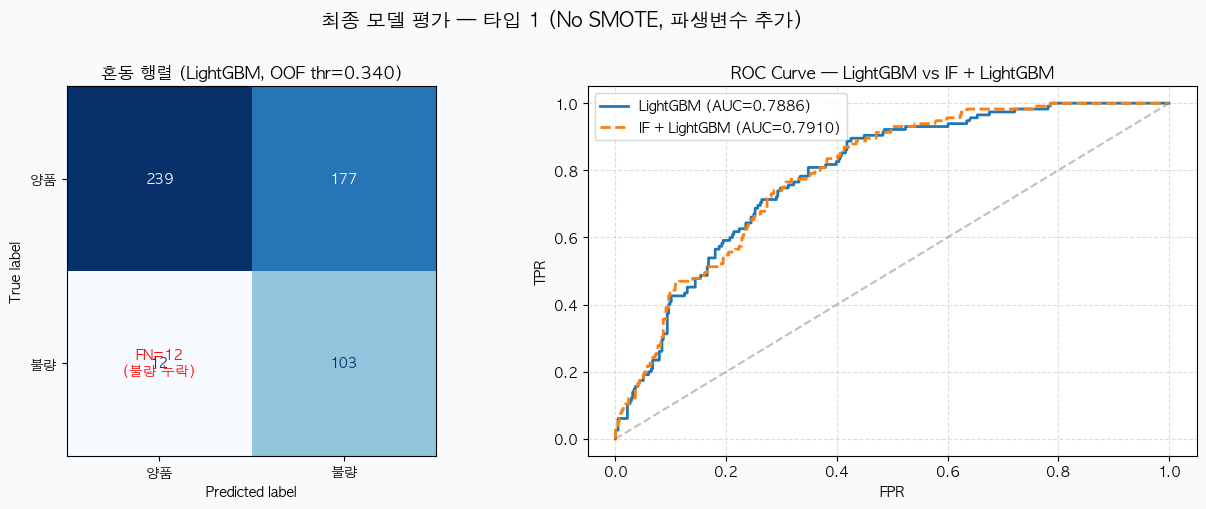

In [121]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve

# ── 타입1: No SMOTE LightGBM
thr1    = oof_thresholds1_ns['LightGBM']
y1_prob = best_lgb1_ns.predict_proba(X1_test)[:, 1]
y1_pred = (y1_prob >= thr1).astype(int)

# ── 타입1: IF + LightGBM
y1_prob_if = lgb1_if.predict_proba(X1_test_if)[:, 1]
y1_pred_if = (y1_prob_if >= thr1_if).astype(int)

print("=" * 55)
print(f"  최종 모델: LightGBM — 타입 1 (No SMOTE)")
print(f"  임계값: {thr1:.3f} (OOF 기준)")
print(f"  피처: {len(FEATURES)}개 (원본 21 + 파생변수 {len(FEATURES)-21}개)")
print("=" * 55)
print(classification_report(y1_test, y1_pred, target_names=['양품', '불량'], digits=4))

fpr_l1,  tpr_l1,  _ = roc_curve(y1_test, y1_prob)
fpr_if1, tpr_if1, _ = roc_curve(y1_test, y1_prob_if)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#F8FAFB')
cm1 = confusion_matrix(y1_test, y1_pred)
ConfusionMatrixDisplay(cm1, display_labels=['양품', '불량']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
tn, fp, fn, tp = cm1.ravel()
axes[0].set_title(f'혼동 행렬 (LightGBM, OOF thr={thr1:.3f})', fontweight='bold')
axes[0].text(0, 1, f'FN={fn}\n(불량 누락)', ha='center', va='center',
             fontsize=10, color='red', fontweight='bold')

axes[1].plot(fpr_l1,  tpr_l1,  lw=2,
             label=f'LightGBM (AUC={roc_auc_score(y1_test, y1_prob):.4f})')
axes[1].plot(fpr_if1, tpr_if1, lw=2, linestyle='--',
             label=f'IF + LightGBM (AUC={roc_auc_score(y1_test, y1_prob_if):.4f})')
axes[1].plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve — LightGBM vs IF + LightGBM', fontweight='bold')
axes[1].legend(); axes[1].grid(linestyle='--', alpha=0.4)
plt.suptitle('최종 모델 평가 — 타입 1 (No SMOTE, 파생변수 추가)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


  최종 모델: IF + XGBoost — 타입 2 (SMOTE 0.4)
  임계값: 0.140 (OOF 기준)
  피처: 27개 (원본+파생변수 26개 + anomaly_score)
              precision    recall  f1-score   support

          양품     0.9110    0.4524    0.6045       294
          불량     0.3482    0.8687    0.4971        99

    accuracy                         0.5573       393
   macro avg     0.6296    0.6605    0.5508       393
weighted avg     0.7692    0.5573    0.5775       393



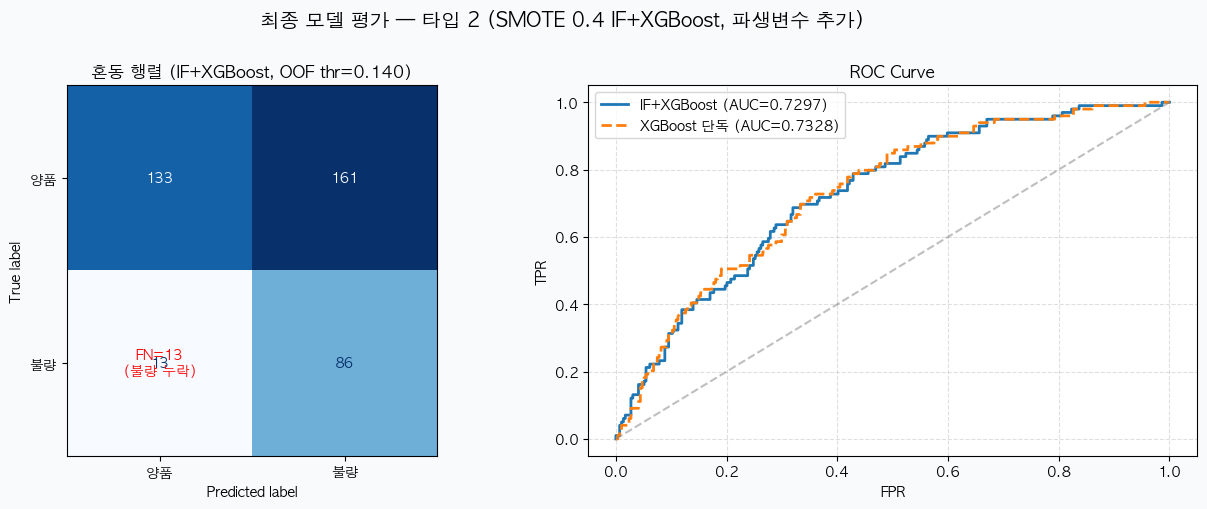

In [61]:
# ── 타입2: SMOTE 0.4 IF + XGBoost
y2_pred = (y2_prob_if >= thr2_if).astype(int)
y2_prob_xgb_base = best_xgb2_sm04.predict_proba(X2_test_xgb)[:, 1]  # 단독 XGBoost 비교용

print("=" * 55)
print(f"  최종 모델: IF + XGBoost — 타입 2 (SMOTE 0.4)")
print(f"  임계값: {thr2_if:.3f} (OOF 기준)")
print(f"  피처: {len(FEATURES)+1}개 (원본+파생변수 {len(FEATURES)}개 + anomaly_score)")
print("=" * 55)
print(classification_report(y2_test, y2_pred, target_names=['양품', '불량'], digits=4))

fpr_if2, tpr_if2, _ = roc_curve(y2_test, y2_prob_if)
fpr_x2,  tpr_x2,  _ = roc_curve(y2_test, y2_prob_xgb_base)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#F8FAFB')
cm2 = confusion_matrix(y2_test, y2_pred)
ConfusionMatrixDisplay(cm2, display_labels=['양품', '불량']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
tn, fp, fn, tp = cm2.ravel()
axes[0].set_title(f'혼동 행렬 (IF+XGBoost, OOF thr={thr2_if:.3f})', fontweight='bold')
axes[0].text(0, 1, f'FN={fn}\n(불량 누락)', ha='center', va='center',
             fontsize=10, color='red', fontweight='bold')
axes[1].plot(fpr_if2, tpr_if2, lw=2,
             label=f'IF+XGBoost (AUC={roc_auc_score(y2_test, y2_prob_if):.4f})')
axes[1].plot(fpr_x2,  tpr_x2,  lw=2, linestyle='--',
             label=f'XGBoost 단독 (AUC={roc_auc_score(y2_test, y2_prob_xgb_base):.4f})')
axes[1].plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(); axes[1].grid(linestyle='--', alpha=0.4)
plt.suptitle('최종 모델 평가 — 타입 2 (SMOTE 0.4 IF+XGBoost, 파생변수 추가)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

  최종 모델: XGBoost 단독 — 타입 2 (SMOTE 0.4)
  임계값: 0.150 (OOF 기준)
  피처: 26개 (원본+파생변수)
              precision    recall  f1-score   support

          양품     0.9114    0.4898    0.6372       294
          불량     0.3617    0.8586    0.5090        99

    accuracy                         0.5827       393
   macro avg     0.6365    0.6742    0.5731       393
weighted avg     0.7729    0.5827    0.6049       393



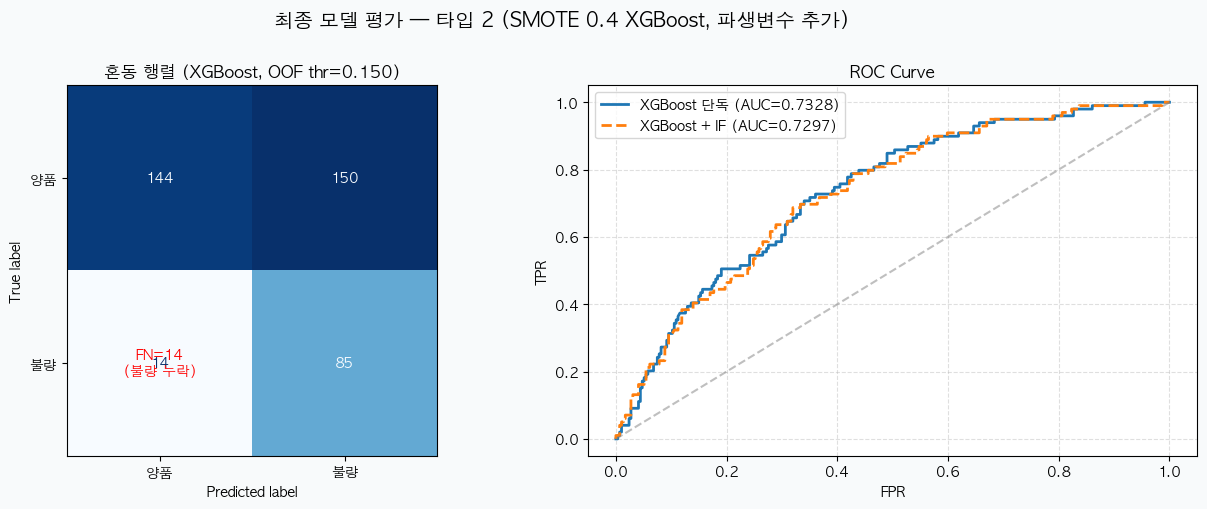

In [113]:
# ── 타입2: SMOTE 0.4 XGBoost 단독
y2_pred = (y2_prob_final >= opt_thr2_xgb).astype(int)

print("=" * 55)
print(f"  최종 모델: XGBoost 단독 — 타입 2 (SMOTE 0.4)")
print(f"  임계값: {opt_thr2_xgb:.3f} (OOF 기준)")
print(f"  피처: {len(FEATURES)}개 (원본+파생변수)")
print("=" * 55)
print(classification_report(y2_test, y2_pred, target_names=['양품', '불량'], digits=4))

fpr_x2,  tpr_x2,  _ = roc_curve(y2_test, y2_prob_final)
fpr_if2, tpr_if2, _ = roc_curve(y2_test, y2_prob_if)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#F8FAFB')
cm2 = confusion_matrix(y2_test, y2_pred)
ConfusionMatrixDisplay(cm2, display_labels=['양품', '불량']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
tn, fp, fn, tp = cm2.ravel()
axes[0].set_title(f'혼동 행렬 (XGBoost, OOF thr={opt_thr2_xgb:.3f})', fontweight='bold')
axes[0].text(0, 1, f'FN={fn}\n(불량 누락)', ha='center', va='center',
             fontsize=10, color='red', fontweight='bold')

axes[1].plot(fpr_x2,  tpr_x2,  lw=2,
             label=f'XGBoost 단독 (AUC={roc_auc_score(y2_test, y2_prob_final):.4f})')
axes[1].plot(fpr_if2, tpr_if2, lw=2, linestyle='--',
             label=f'XGBoost + IF (AUC={roc_auc_score(y2_test, y2_prob_if):.4f})')
axes[1].plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(); axes[1].grid(linestyle='--', alpha=0.4)

plt.suptitle('최종 모델 평가 — 타입 2 (SMOTE 0.4 XGBoost, 파생변수 추가)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

[ SHAP 분석 — 타입 1 (No SMOTE LightGBM) ]


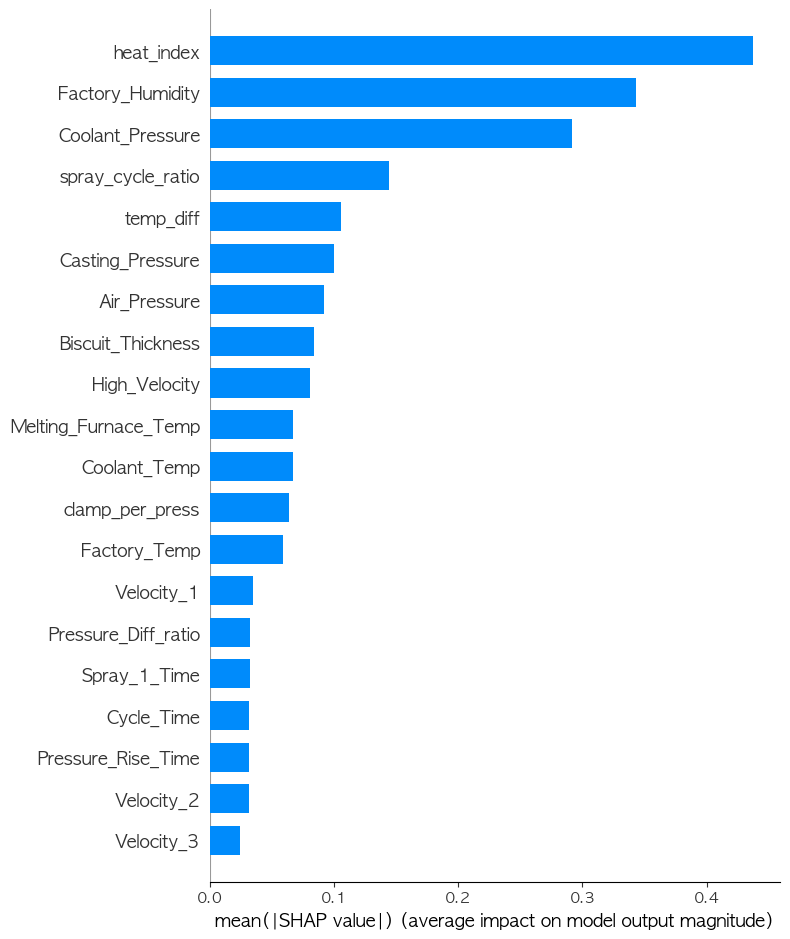

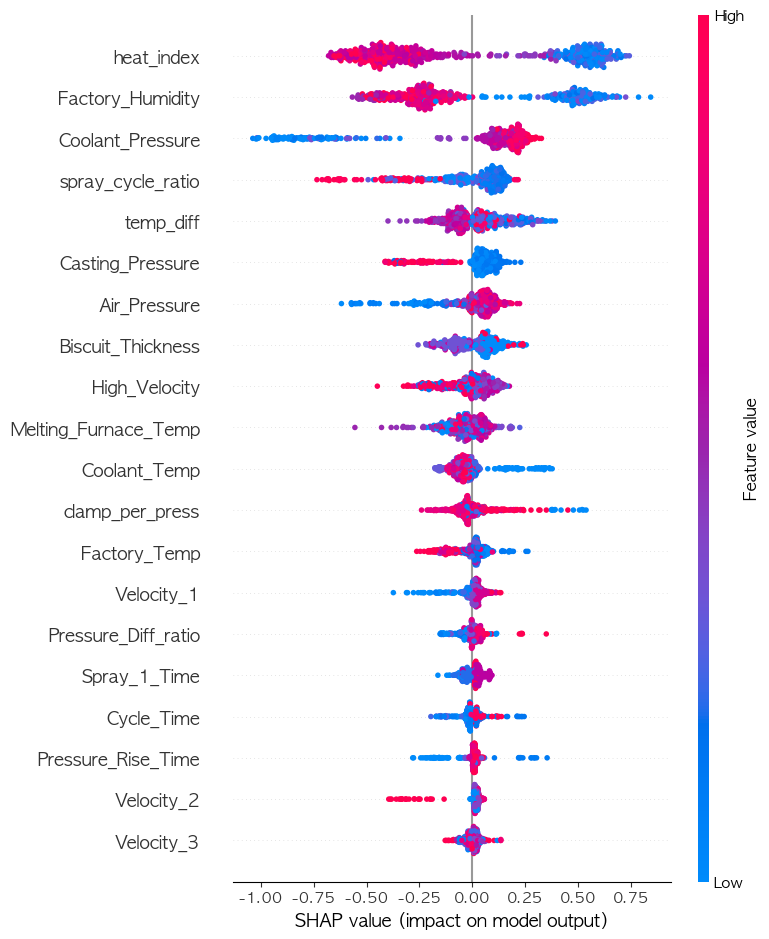

In [114]:
import shap
import warnings
warnings.filterwarnings('ignore')

# ── 타입1: No SMOTE LightGBM SHAP
print("[ SHAP 분석 — 타입 1 (No SMOTE LightGBM) ]")
explainer1 = shap.TreeExplainer(best_lgb1_ns)
shap_values1 = explainer1.shap_values(X1_test)
shap_values1_array = shap_values1[1] if isinstance(shap_values1, list) else shap_values1

shap.summary_plot(shap_values1_array, X1_test, plot_type='bar', show=True)
shap.summary_plot(shap_values1_array, X1_test, show=True)

[ SHAP 분석 — 타입 2 (SMOTE 0.4 XGBoost 단독) ]


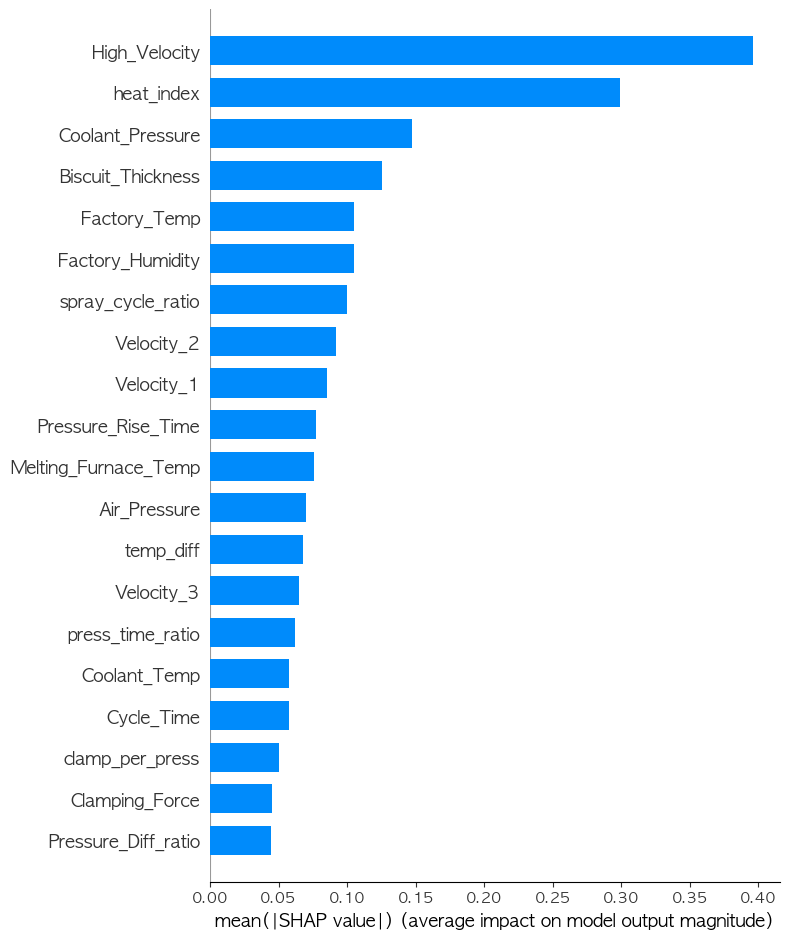

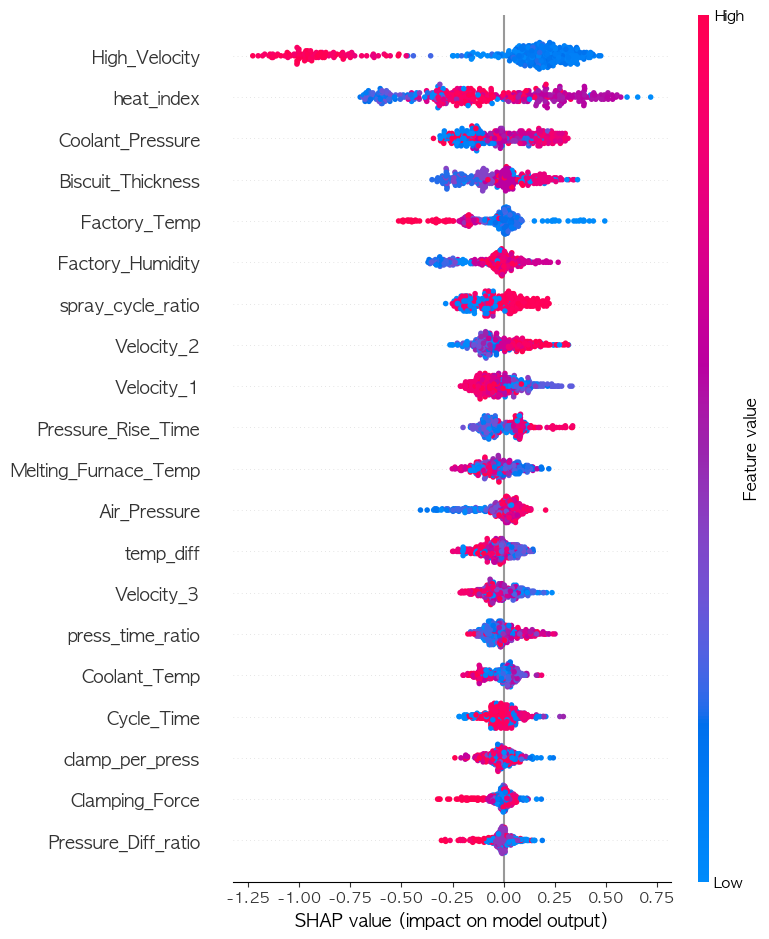

In [115]:
# ── 타입2: XGBoost 단독 SHAP
print("[ SHAP 분석 — 타입 2 (SMOTE 0.4 XGBoost 단독) ]")
explainer2 = shap.TreeExplainer(best_xgb2_sm04)
shap_values2 = explainer2.shap_values(X2_test_xgb)
shap_values2_array = shap_values2[1] if isinstance(shap_values2, list) else shap_values2

shap.summary_plot(shap_values2_array, X2_test_xgb, plot_type='bar', show=True)
shap.summary_plot(shap_values2_array, X2_test_xgb, show=True)

타입1 SHAP 상위 6개: ['heat_index', 'Factory_Humidity', 'Coolant_Pressure', 'spray_cycle_ratio', 'temp_diff', 'Casting_Pressure']
타입2 SHAP 상위 6개: ['High_Velocity', 'heat_index', 'Coolant_Pressure', 'Biscuit_Thickness', 'Factory_Temp', 'Factory_Humidity']

[ SHAP Dependence Plot — 타입 1 (No SMOTE LightGBM) ]


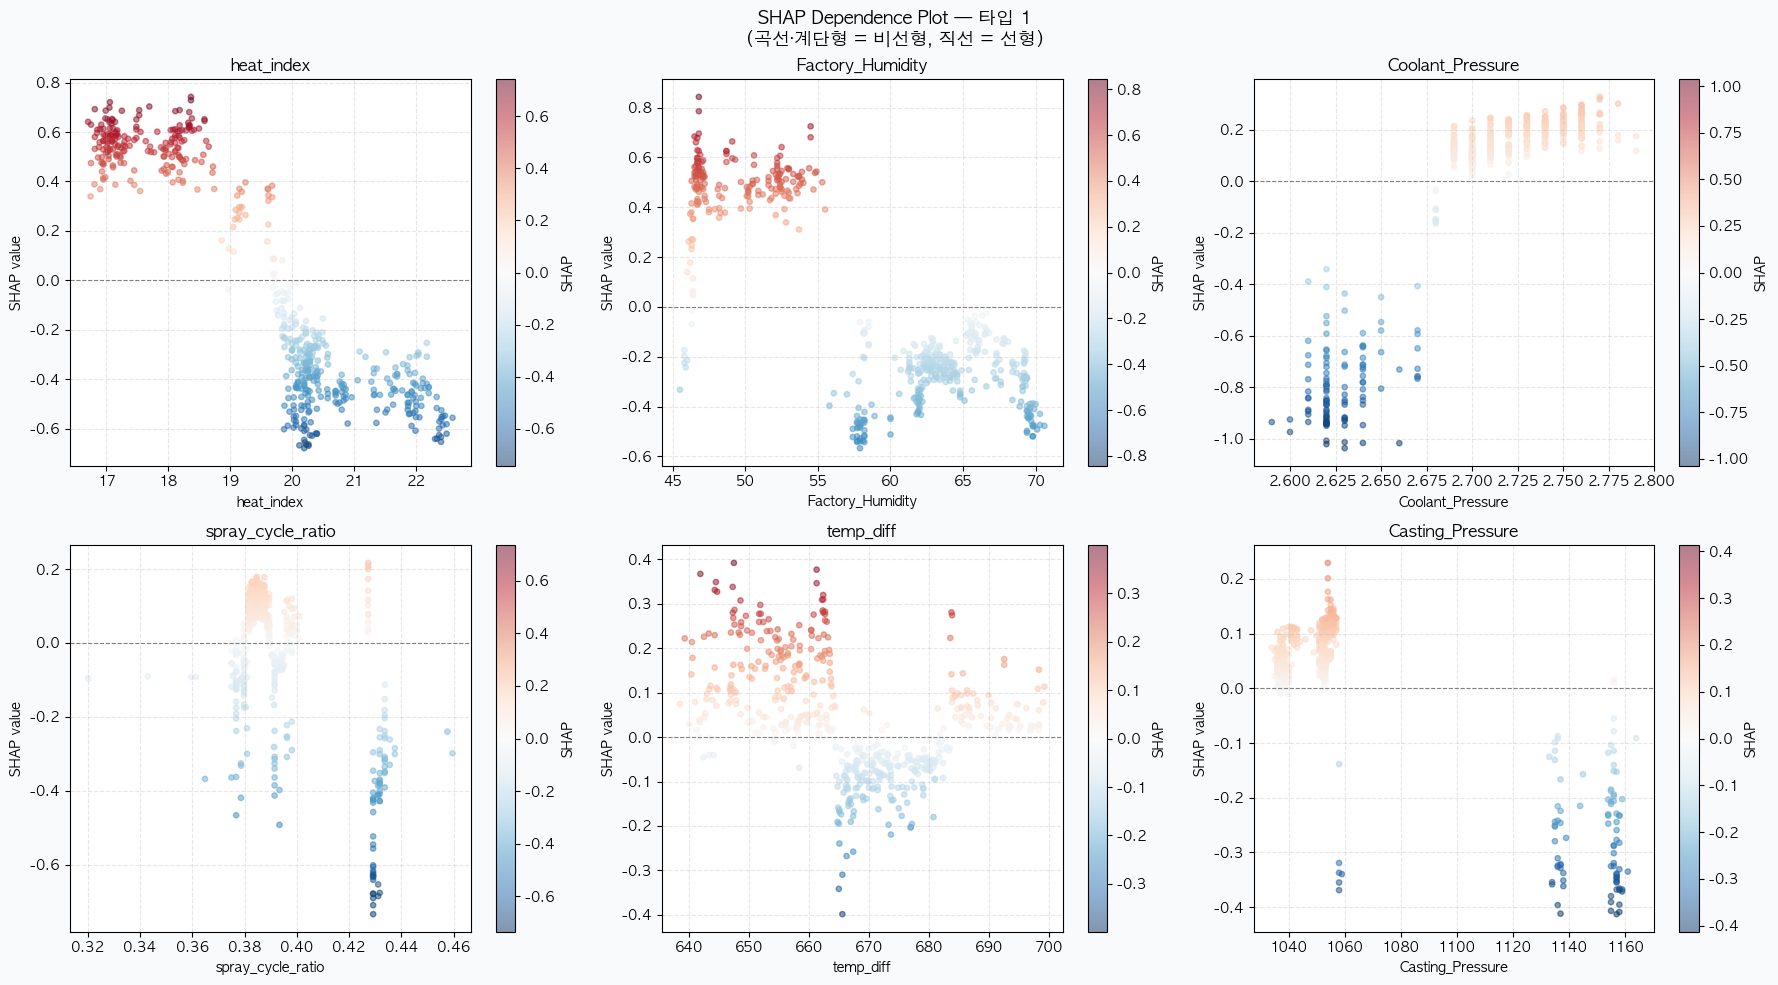


[ SHAP Dependence Plot — 타입 2 (SMOTE 0.4 XGBoost 단독) ]


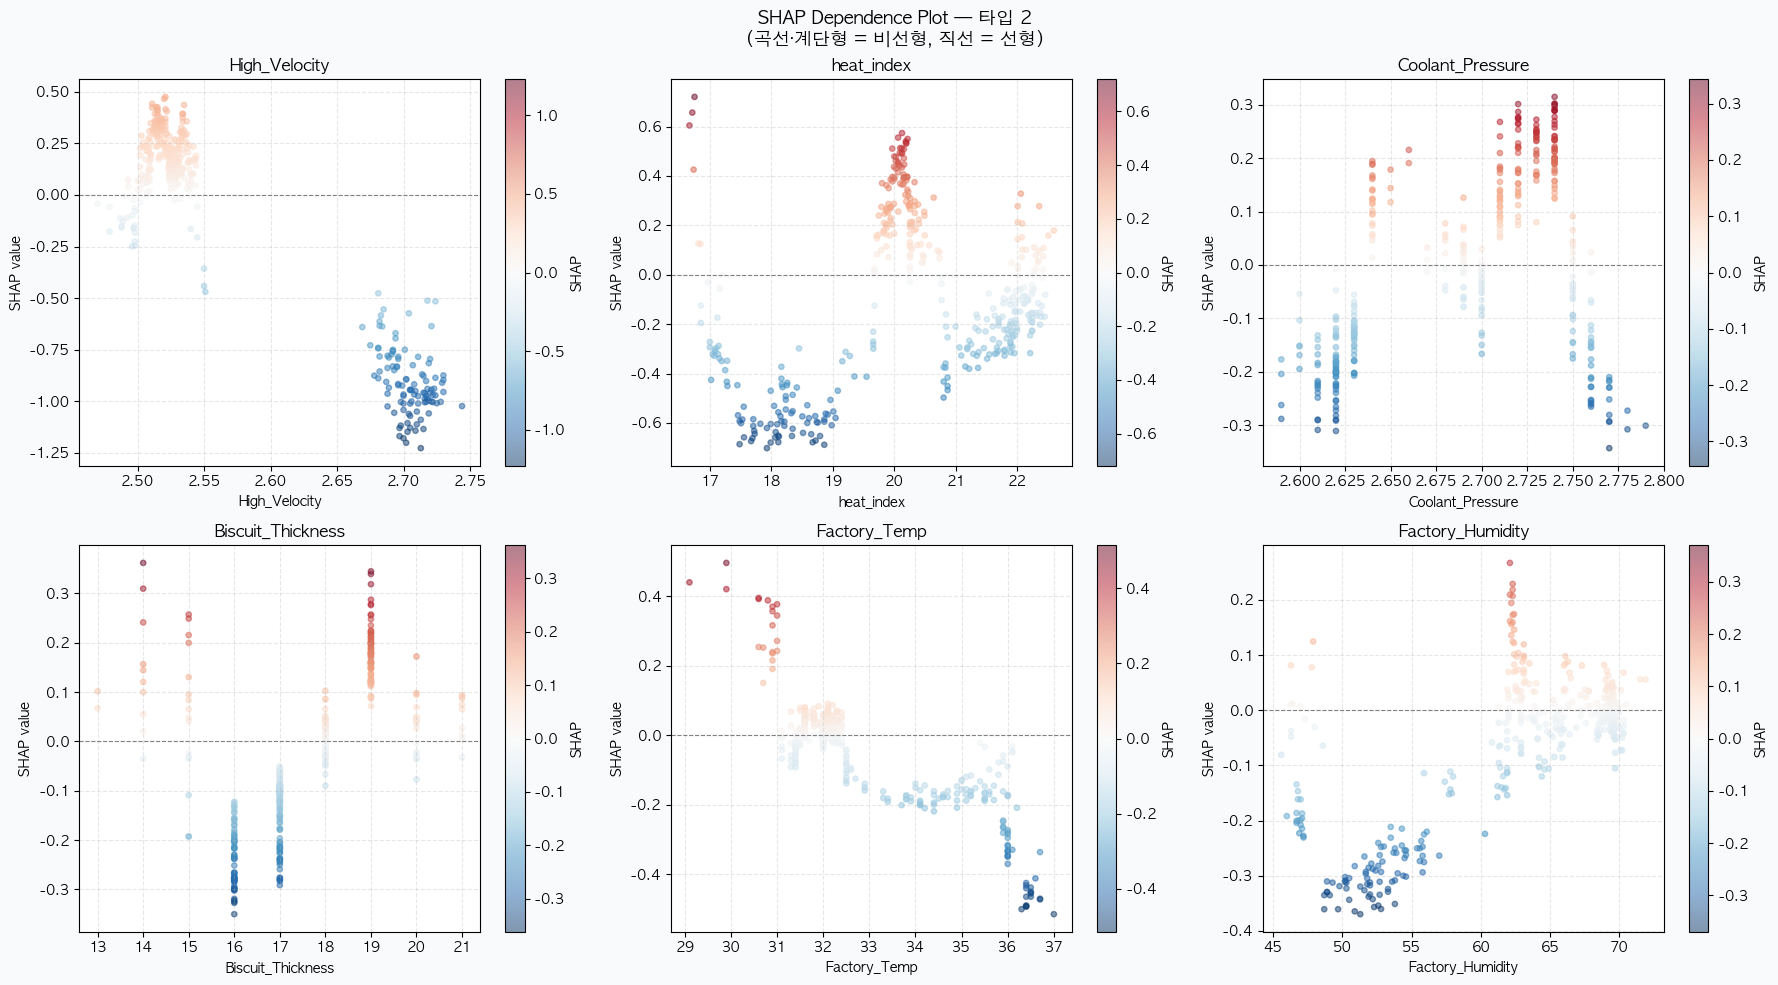

In [120]:
# ── SHAP 상위 6개 변수 동적 산출
import pandas as pd, numpy as np

dep_vars1 = pd.Series(
    np.abs(shap_values1_array).mean(axis=0),
    index=X1_test.columns
).sort_values(ascending=False).head(6).index.tolist()

dep_vars2 = pd.Series(
    np.abs(shap_values2_array).mean(axis=0),
    index=X2_test_xgb.columns  # ← 수정
).sort_values(ascending=False).head(6).index.tolist()

print(f"타입1 SHAP 상위 6개: {dep_vars1}")
print(f"타입2 SHAP 상위 6개: {dep_vars2}")

# ── 타입1 Dependence Plot
print("\n[ SHAP Dependence Plot — 타입 1 (No SMOTE LightGBM) ]")
fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor='#F8FAFB')
axes = axes.flatten()

for i, var in enumerate(dep_vars1):
    feat_idx  = list(X1_test.columns).index(var)
    shap_col  = shap_values1_array[:, feat_idx]
    feat_vals = X1_test[var].values

    sc = axes[i].scatter(feat_vals, shap_col,
                         c=shap_col, cmap='RdBu_r',
                         alpha=0.5, s=15, vmin=-abs(shap_col).max(), vmax=abs(shap_col).max())
    axes[i].axhline(0, color='gray', lw=0.8, linestyle='--')
    axes[i].set_xlabel(var, fontsize=10)
    axes[i].set_ylabel('SHAP value', fontsize=10)
    axes[i].set_title(var, fontweight='bold')
    axes[i].grid(linestyle='--', alpha=0.3)
    plt.colorbar(sc, ax=axes[i], label='SHAP')

plt.suptitle('SHAP Dependence Plot — 타입 1\n(곡선·계단형 = 비선형, 직선 = 선형)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 타입2 Dependence Plot
print("\n[ SHAP Dependence Plot — 타입 2 (SMOTE 0.4 XGBoost 단독) ]")
fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor='#F8FAFB')
axes = axes.flatten()

for i, var in enumerate(dep_vars2):
    feat_idx  = list(X2_test_xgb.columns).index(var)
    shap_col  = shap_values2_array[:, feat_idx]
    feat_vals = X2_test_xgb[var].values

    sc = axes[i].scatter(feat_vals, shap_col,
                         c=shap_col, cmap='RdBu_r',
                         alpha=0.5, s=15, vmin=-abs(shap_col).max(), vmax=abs(shap_col).max())
    axes[i].axhline(0, color='gray', lw=0.8, linestyle='--')
    axes[i].set_xlabel(var, fontsize=10)
    axes[i].set_ylabel('SHAP value', fontsize=10)
    axes[i].set_title(var, fontweight='bold')
    axes[i].grid(linestyle='--', alpha=0.3)
    plt.colorbar(sc, ax=axes[i], label='SHAP')

plt.suptitle('SHAP Dependence Plot — 타입 2\n(곡선·계단형 = 비선형, 직선 = 선형)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## STEP 10. 불량 유형 다중 분류 (Defect_Type)


[ 불량 유형 다중 분류 — Product_Type 타입 1 ]
[ 클래스 분포 ]
Defect_Type
Normal         2075
Exfoliation     196
Short_Shot      165
Deformation     152
Bubble           58
Name: count, dtype: int64

전체 샘플: 2646건

훈련셋: 2116행 / 테스트셋: 530행

[ LightGBM 다중 분류 성능 ]
              precision    recall  f1-score   support

      Bubble     0.0000    0.0000    0.0000        12
 Deformation     0.3077    0.5333    0.3902        30
 Exfoliation     0.1212    0.1026    0.1111        39
      Normal     0.8391    0.8149    0.8268       416
  Short_Shot     0.1333    0.1212    0.1270        33

    accuracy                         0.6849       530
   macro avg     0.2803    0.3144    0.2910       530
weighted avg     0.6933    0.6849    0.6872       530



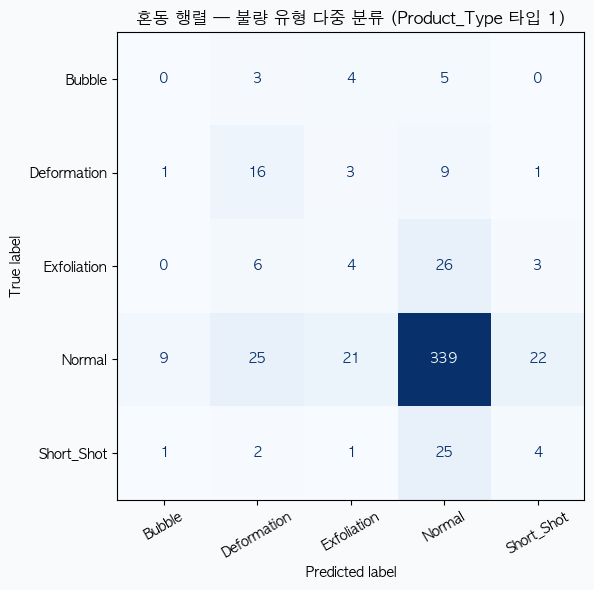


[ 불량 유형 다중 분류 — Product_Type 타입 2 ]
[ 클래스 분포 ]
Defect_Type
Normal        1467
Short_Shot     222
Blow_Hole      169
Stain           70
Name: count, dtype: int64

전체 샘플: 1928건

훈련셋: 1542행 / 테스트셋: 386행

[ LightGBM 다중 분류 성능 ]
              precision    recall  f1-score   support

   Blow_Hole     0.2593    0.4118    0.3182        34
      Normal     0.8359    0.7279    0.7782       294
  Short_Shot     0.2115    0.2500    0.2292        44
       Stain     0.2500    0.4286    0.3158        14

    accuracy                         0.6347       386
   macro avg     0.3892    0.4546    0.4103       386
weighted avg     0.6927    0.6347    0.6583       386



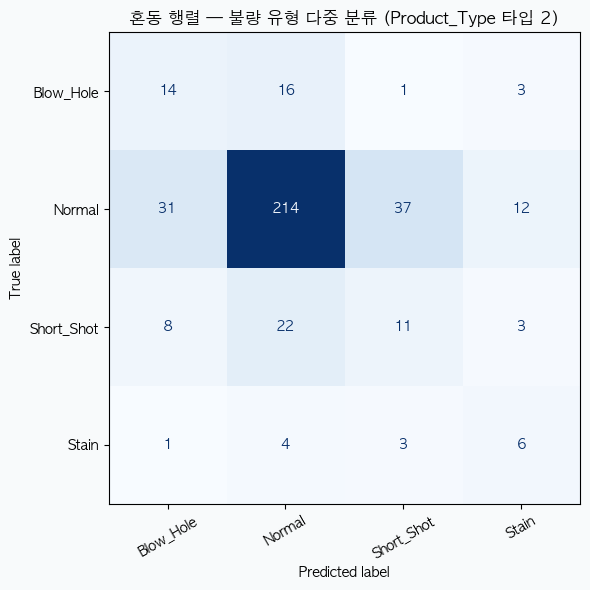

In [117]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ── 타입별 제외 클래스 설정
exclude_map = {
    '타입 1': ['Other', 'Stain'],
    '타입 2': ['Other','Bubble'],  # 타입2 제외 클래스 필요시 수정
}

file_map = {
    '타입 1': '../finals/df_type1_final.csv',
    '타입 2': '../finals/df_type2_final.csv',
}

for label in ['타입 1', '타입 2']:
    print(f"\n{'='*60}")
    print(f"[ 불량 유형 다중 분류 — Product_Type {label} ]")
    print(f"{'='*60}")

    df_multi = pd.read_csv(file_map[label])
    df_multi['Pressure_Diff_ratio'] = df_multi['Casting_Pressure'] / df_multi['Cylinder_Pressure']
    df_multi = df_multi[~df_multi['Defect_Type'].isin(exclude_map[label])].reset_index(drop=True)

    X_multi = df_multi[FEATURES].copy()
    y_multi = df_multi['Defect_Type'].copy()

    print("[ 클래스 분포 ]")
    print(y_multi.value_counts())
    print(f"\n전체 샘플: {len(y_multi)}건")

    X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
        X_multi, y_multi, test_size=0.2, stratify=y_multi, random_state=SEED)
    print(f"\n훈련셋: {X_tr_m.shape[0]}행 / 테스트셋: {X_te_m.shape[0]}행")

    lgb_multi = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.01, num_leaves=127,
        subsample=0.7, class_weight='balanced',
        random_state=SEED, verbose=-1)
    lgb_multi.fit(X_tr_m, y_tr_m)
    y_pred_multi = lgb_multi.predict(X_te_m)

    print("\n[ LightGBM 다중 분류 성능 ]")
    print(classification_report(y_te_m, y_pred_multi, digits=4))

    labels = sorted(y_multi.unique())
    cm_multi = confusion_matrix(y_te_m, y_pred_multi, labels=labels)

    fig, ax = plt.subplots(figsize=(8, 6), facecolor='#F8FAFB')
    ConfusionMatrixDisplay(cm_multi, display_labels=labels).plot(
        ax=ax, colorbar=False, cmap='Blues', xticks_rotation=30)
    ax.set_title(f'혼동 행렬 — 불량 유형 다중 분류 (Product_Type {label})', fontweight='bold')
    plt.tight_layout()
    plt.show()

## STEP 9-1. 불량 유형 다중 분류 — Normal 제외 (불량끼리만)


[ 불량 유형 다중 분류 — Product_Type 타입 1 ]
[ 클래스 분포 (Normal 제외) ]
Defect_Type
Exfoliation    196
Short_Shot     165
Deformation    152
Bubble          58
Name: count, dtype: int64

전체 샘플: 571건
훈련셋: 456행 / 테스트셋: 115행

[ 베이스라인 (SMOTE 없음) ]
              precision    recall  f1-score   support

      Bubble     0.2000    0.1667    0.1818        12
 Deformation     0.4359    0.5484    0.4857        31
 Exfoliation     0.4762    0.5128    0.4938        39
  Short_Shot     0.5000    0.3636    0.4211        33

    accuracy                         0.4435       115
   macro avg     0.4030    0.3979    0.3956       115
weighted avg     0.4433    0.4435    0.4382       115

[ SMOTE 후 클래스 분포 ]
Defect_Type
Exfoliation    157
Bubble         157
Deformation    157
Short_Shot     157
Name: count, dtype: int64

[ SMOTE 적용 후 ]
              precision    recall  f1-score   support

      Bubble     0.2000    0.1667    0.1818        12
 Deformation     0.4737    0.5806    0.5217        31
 Exfoliation     0.50

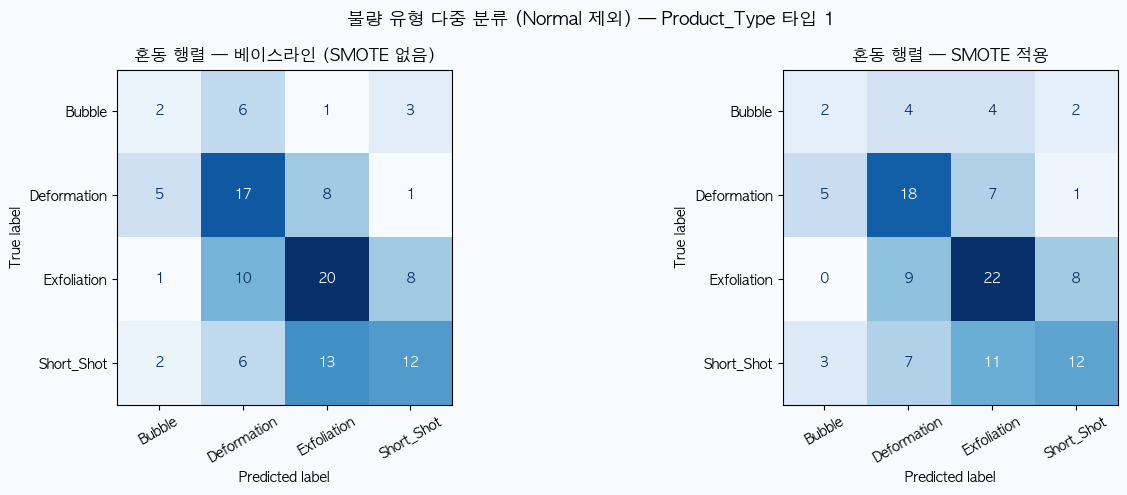


[ 불량 유형 다중 분류 — Product_Type 타입 2 ]
[ 클래스 분포 (Normal 제외) ]
Defect_Type
Short_Shot    222
Blow_Hole     169
Stain          70
Name: count, dtype: int64

전체 샘플: 461건
훈련셋: 368행 / 테스트셋: 93행

[ 베이스라인 (SMOTE 없음) ]
              precision    recall  f1-score   support

   Blow_Hole     0.6774    0.6176    0.6462        34
  Short_Shot     0.6667    0.6667    0.6667        45
       Stain     0.3529    0.4286    0.3871        14

    accuracy                         0.6129        93
   macro avg     0.5657    0.5710    0.5666        93
weighted avg     0.6234    0.6129    0.6171        93

[ SMOTE 후 클래스 분포 ]
Defect_Type
Blow_Hole     177
Stain         177
Short_Shot    177
Name: count, dtype: int64

[ SMOTE 적용 후 ]
              precision    recall  f1-score   support

   Blow_Hole     0.6970    0.6765    0.6866        34
  Short_Shot     0.6889    0.6889    0.6889        45
       Stain     0.3333    0.3571    0.3448        14

    accuracy                         0.6344        93
   macro av

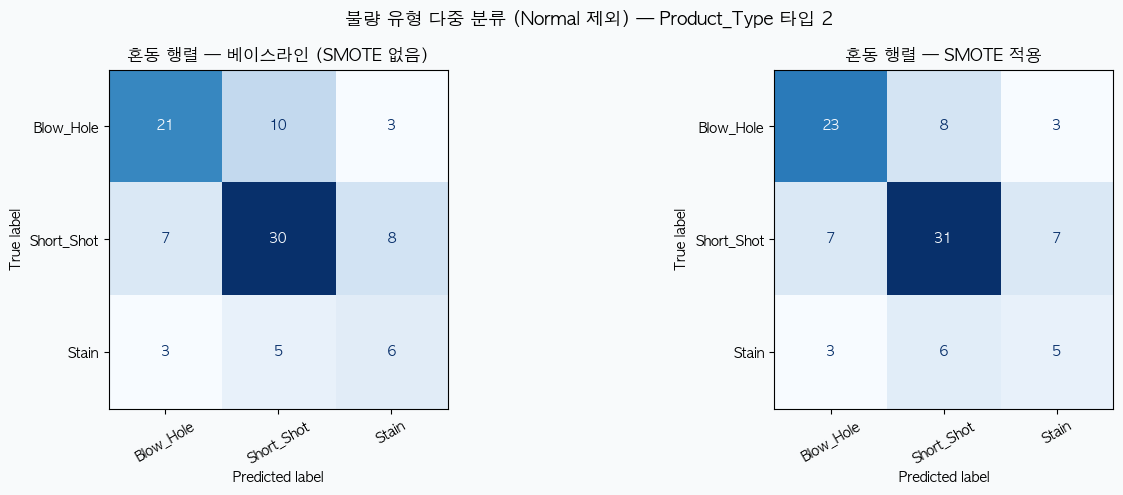

In [110]:
from imblearn.over_sampling import SMOTE

exclude_map = {
    '타입 1': ['Other', 'Stain'],
    '타입 2': ['Other', 'Bubble'],
}

defect_types_map = {
    '타입 1': type1_df,
    '타입 2': type2_df,
}

for label, df in defect_types_map.items():
    print(f"\n{'='*60}")
    print(f"[ 불량 유형 다중 분류 — Product_Type {label} ]")
    print(f"{'='*60}")

    type_defect = df[
        (df['Defect_Type'] != 'Normal') &
        (~df['Defect_Type'].isin(exclude_map[label]))
    ].reset_index(drop=True)

    X_def = type_defect[FEATURES].copy()
    y_def = type_defect['Defect_Type'].copy()

    print("[ 클래스 분포 (Normal 제외) ]")
    print(y_def.value_counts())
    print(f"\n전체 샘플: {len(y_def)}건")

    X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(
        X_def, y_def, test_size=0.2, stratify=y_def, random_state=SEED)
    print(f"훈련셋: {X_tr_d.shape[0]}행 / 테스트셋: {X_te_d.shape[0]}행")

    # ── 베이스라인
    lgb_def = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.01, num_leaves=63,
        subsample=0.7, class_weight='balanced',
        random_state=SEED, verbose=-1)
    lgb_def.fit(X_tr_d, y_tr_d)
    y_pred_def = lgb_def.predict(X_te_d)

    print("\n[ 베이스라인 (SMOTE 없음) ]")
    print(classification_report(y_te_d, y_pred_def, digits=4))

    # ── SMOTE 적용
    smote_def = SMOTE(random_state=SEED, k_neighbors=3)
    X_tr_d_sm, y_tr_d_sm = smote_def.fit_resample(X_tr_d, y_tr_d)

    print("[ SMOTE 후 클래스 분포 ]")
    print(pd.Series(y_tr_d_sm).value_counts())

    lgb_def_sm = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.01, num_leaves=63,
        subsample=0.7, class_weight='balanced',
        random_state=SEED, verbose=-1)
    lgb_def_sm.fit(X_tr_d_sm, y_tr_d_sm)
    y_pred_def_sm = lgb_def_sm.predict(X_te_d)

    print("\n[ SMOTE 적용 후 ]")
    print(classification_report(y_te_d, y_pred_def_sm, digits=4))

    # ── 혼동 행렬
    labels_def = sorted(y_def.unique())
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#F8FAFB')

    for ax, y_pred_plot, title in zip(
        axes,
        [y_pred_def, y_pred_def_sm],
        ['베이스라인 (SMOTE 없음)', 'SMOTE 적용']
    ):
        cm_def = confusion_matrix(y_te_d, y_pred_plot, labels=labels_def)
        ConfusionMatrixDisplay(cm_def, display_labels=labels_def).plot(
            ax=ax, colorbar=False, cmap='Blues', xticks_rotation=30)
        ax.set_title(f'혼동 행렬 — {title}', fontweight='bold')

    plt.suptitle(f'불량 유형 다중 분류 (Normal 제외) — Product_Type {label}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [ ]:
#with open('model_type1_lgbm.pkl', 'wb') as f:
    #pickle.dump({'model': best_lgb, 'threshold': float(opt_thr_lgbm), 'features': list(X_train.columns)}, f)

타입1 SHAP 상위 6개: ['heat_index', 'Factory_Humidity', 'Coolant_Pressure', 'spray_cycle_ratio', 'temp_diff', 'Casting_Pressure']
타입2 SHAP 상위 6개: ['High_Velocity', 'heat_index', 'Coolant_Pressure', 'Biscuit_Thickness', 'Factory_Temp', 'Factory_Humidity']

[ 시나리오 시뮬레이션 — Product_Type 타입 1 ]


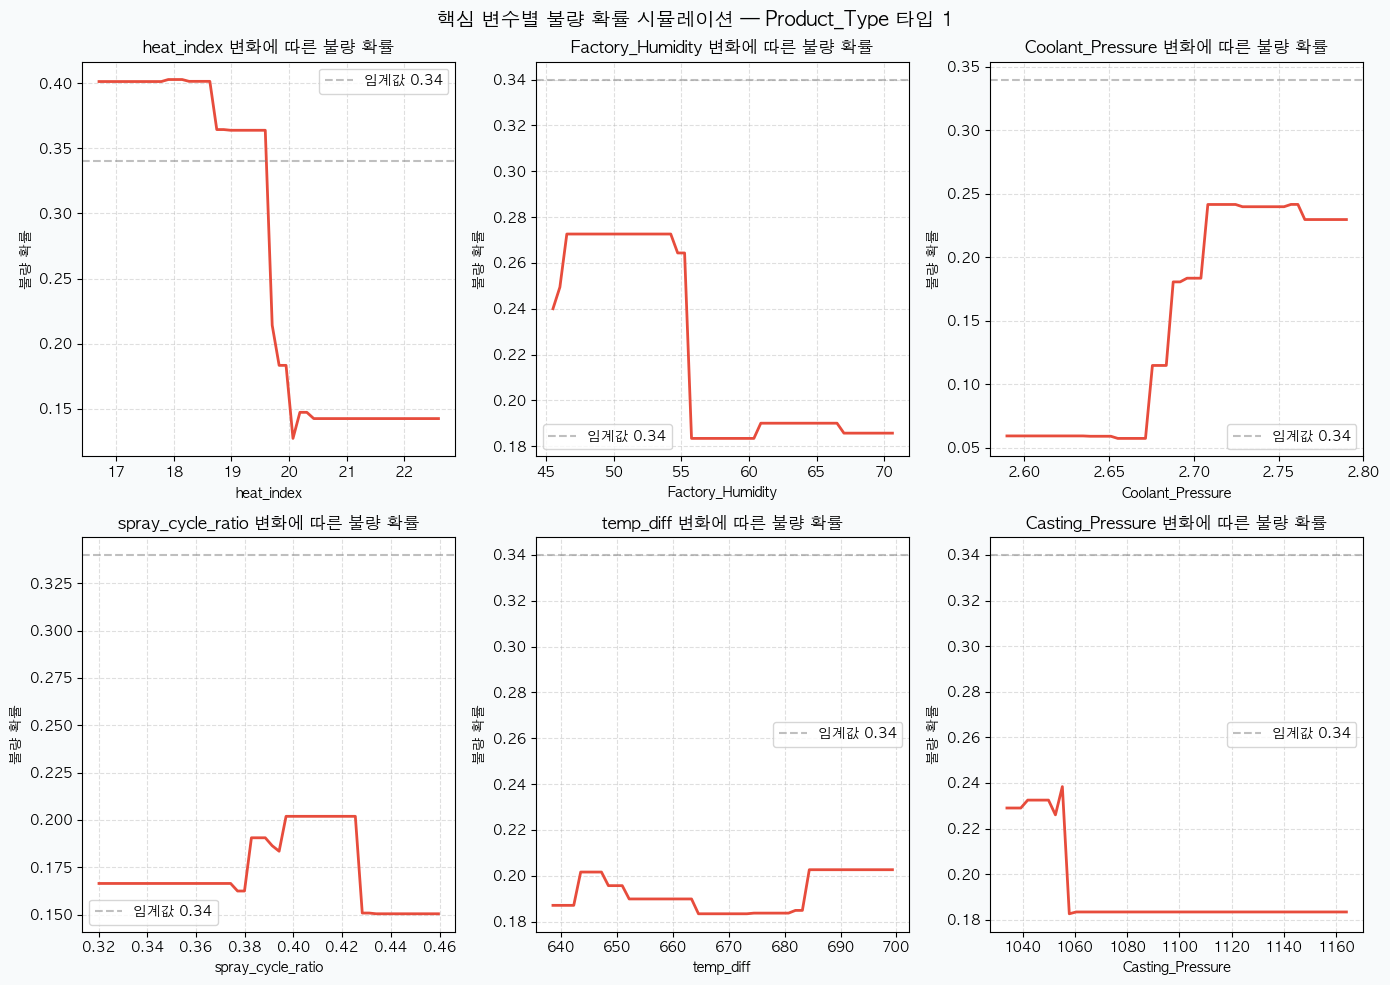

  최적 공정 조건 (불량 확률 하위 10%) — 타입 1
      heat_index  Factory_Humidity  Coolant_Pressure  spray_cycle_ratio  \
mean     21.5356           65.6902            2.6227             0.4185   
min      20.1474           57.4000            2.6000             0.3202   
max      22.5920           70.6000            2.6500             0.4596   

      temp_diff  Casting_Pressure    불량확률  
mean   678.5805         1149.9024  0.0235  
min    647.1000         1039.0000  0.0141  
max    698.4000         1161.0000  0.0355  

 최적 조건 요약:
  heat_index: 21.54 (범위 20.15 ~ 22.59)
  Factory_Humidity: 65.69 (범위 57.40 ~ 70.60)
  Coolant_Pressure: 2.62 (범위 2.60 ~ 2.65)
  spray_cycle_ratio: 0.42 (범위 0.32 ~ 0.46)
  temp_diff: 678.58 (범위 647.10 ~ 698.40)
  Casting_Pressure: 1149.90 (범위 1039.00 ~ 1161.00)

[ 시나리오 시뮬레이션 — Product_Type 타입 2 ]


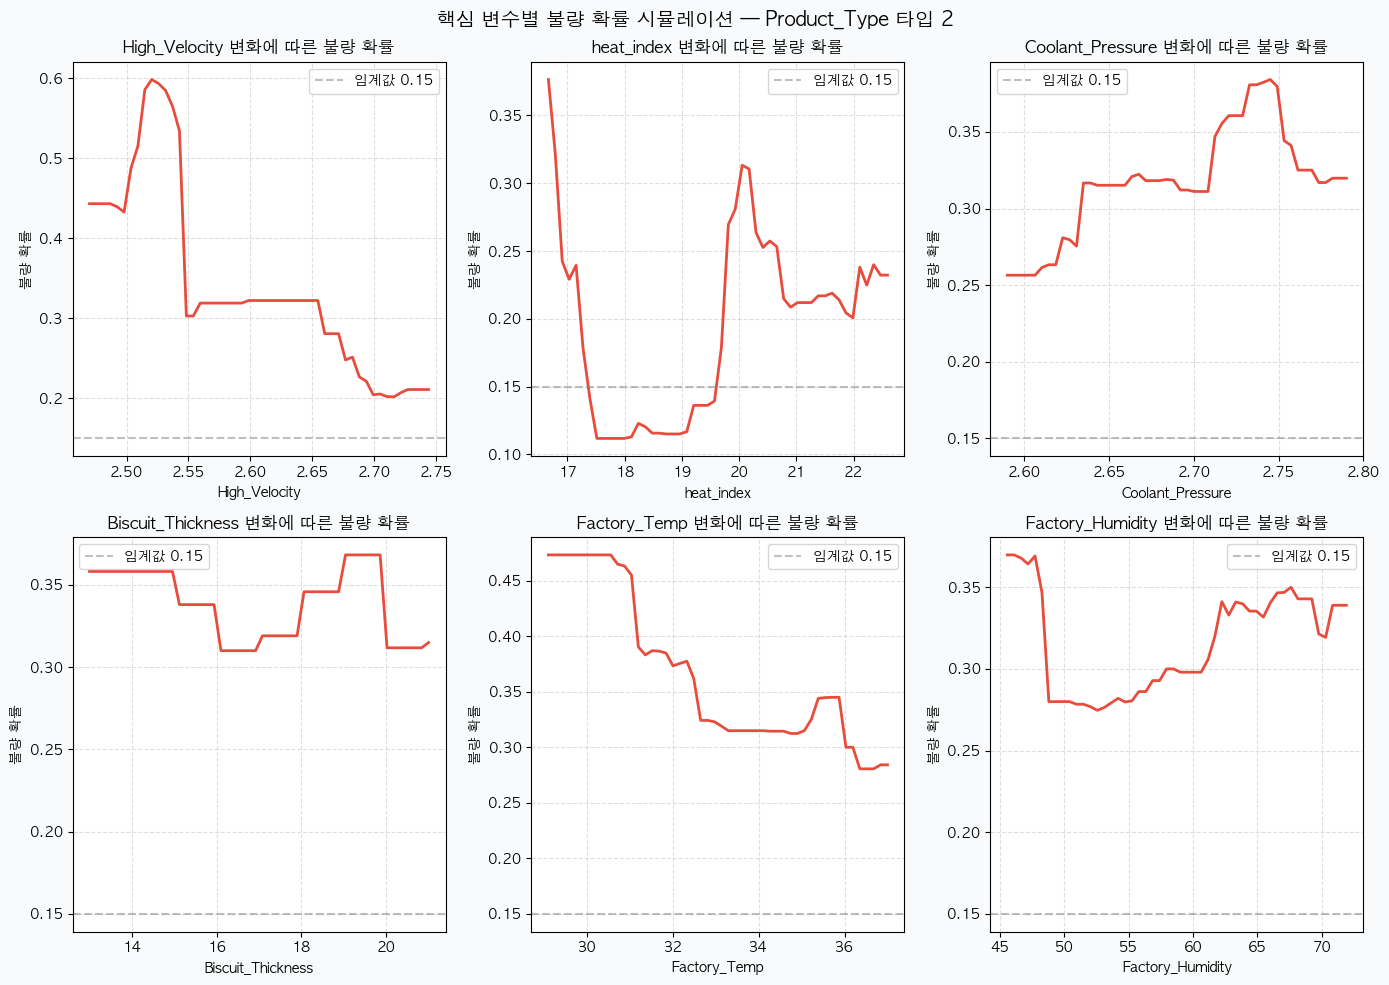

  최적 공정 조건 (불량 확률 하위 10%) — 타입 2
      High_Velocity  heat_index  Coolant_Pressure  Biscuit_Thickness  \
mean         2.7079     18.0159            2.6966            16.7241   
min          2.6820     17.0200            2.6800            14.0000   
max          2.7440     19.6560            2.7200            20.0000   

      Factory_Temp  Factory_Humidity    불량확률  
mean       35.4241           50.9207  0.0219  
min        33.3000           46.0000  0.0157  
max        37.0000           55.9000  0.0281  

 최적 조건 요약:
  High_Velocity: 2.71 (범위 2.68 ~ 2.74)
  heat_index: 18.02 (범위 17.02 ~ 19.66)
  Coolant_Pressure: 2.70 (범위 2.68 ~ 2.72)
  Biscuit_Thickness: 16.72 (범위 14.00 ~ 20.00)
  Factory_Temp: 35.42 (범위 33.30 ~ 37.00)
  Factory_Humidity: 50.92 (범위 46.00 ~ 55.90)


In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── SHAP 기준 타입별 상위 6개 변수
key_vars1 = pd.Series(
    np.abs(shap_values1_array).mean(axis=0),
    index=X1_test.columns
).sort_values(ascending=False).head(6).index.tolist()

key_vars2 = pd.Series(
    np.abs(shap_values2_array).mean(axis=0),
    index=X2_test_xgb.columns
).sort_values(ascending=False).head(6).index.tolist()

print(f"타입1 SHAP 상위 6개: {key_vars1}")
print(f"타입2 SHAP 상위 6개: {key_vars2}")

configs = {
    '타입 1': (best_lgb1_ns,   X1_test,     y1_test, key_vars1, oof_thresholds1_ns['LightGBM']),
    '타입 2': (best_xgb2_sm04, X2_test_xgb, y2_test, key_vars2, opt_thr2_xgb),
}

for label, (model, X_te, y_te, key_vars, thr) in configs.items():
    print(f"\n{'='*60}")
    print(f"[ 시나리오 시뮬레이션 — Product_Type {label} ]")
    print(f"{'='*60}")

    baseline = X_te[y_te == 0].mean().to_dict()

    # ── 1. 시나리오 시뮬레이션
    fig, axes = plt.subplots(2, 3, figsize=(14, 10), facecolor='#F8FAFB')
    axes = axes.flatten()

    for i, var in enumerate(key_vars):
        probs = []
        var_range = np.linspace(X_te[var].min(), X_te[var].max(), 50)

        for val in var_range:
            sample = pd.DataFrame([baseline])
            sample[var] = val
            prob = model.predict_proba(sample)[:, 1][0]
            probs.append(prob)

        axes[i].plot(var_range, probs, color='#E74C3C', lw=2)
        axes[i].axhline(thr, color='gray', linestyle='--', alpha=0.5, label=f'임계값 {thr:.2f}')
        axes[i].set_xlabel(var)
        axes[i].set_ylabel('불량 확률')
        axes[i].set_title(f'{var} 변화에 따른 불량 확률', fontweight='bold')
        axes[i].legend()
        axes[i].grid(linestyle='--', alpha=0.4)

    plt.suptitle(f'핵심 변수별 불량 확률 시뮬레이션 — Product_Type {label}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── 2. 최적 공정 조건 탐색
    normal_data = X_te[y_te == 0].copy()
    normal_data['불량확률'] = model.predict_proba(normal_data)[:, 1]
    normal_data = normal_data.sort_values('불량확률')

    print("=" * 55)
    print(f"  최적 공정 조건 (불량 확률 하위 10%) — {label}")
    print("=" * 55)
    top10 = normal_data.head(int(len(normal_data) * 0.1))
    optimal = top10[key_vars + ['불량확률']].describe().loc[['mean', 'min', 'max']]
    print(optimal.round(4))

    print("\n 최적 조건 요약:")
    for var in key_vars:
        print(f"  {var}: {top10[var].mean():.2f} (범위 {top10[var].min():.2f} ~ {top10[var].max():.2f})")